## E-Commerce Customer Churn🛍️
**Author by : Lauzia Fadhila Nareswari**

## A. Business Problem & Understanding

**Background**:
- E-commerce adalah model bisnis yang memungkinkan perusahaan dan konsumen melakukan transaksi jual-beli produk atau jasa secara elektronik melalui internet.
- Kumpulan data ini milik sebuah perusahaan e-commerce online terkemuka. Perusahaan ritel online (e-commerce) ingin mengetahui **pelanggan mana yang akan berhenti berlangganan**, sehingga mereka dapat mendekati pelanggan untuk menawarkan beberapa promosi.

*The data set belongs to a leading online E-commerce company. An online retail (E-commerce) company wants to know the customers who are going to churn, so accordingly, they can approach customers to offer some promos.*

**(A.1) Rumusan Masalah**: Perusahaan E-commerce kehilangan pelanggan (churn).
- Pelanggan mana yg kemungkinan besar akan churn dalam waktu dekat?
- Mendapatkan pelanggan baru jauh lebih mahal daripada mempertahankan pelanggan yang sudah ada.
- Churn rate saat ini 16.3% dari total pelanggan aktif.
- Setiap pelanggan yg churn = kehilangan potensi revenue dan biaya akuisisi
- Target : **mendeteksi minimal 80% pelanggan yg akan churn agar tim retensi bisa melakukan intervensi tepat waktu.**

**(A.2) Goals**
- Membangun **model klasifikasi** untuk memprediksi apakah seorang pelanggan akan churn atau tidak
- Membangun model dengan **recall ≥ 0.80** pada kelas churn
- Memberikan rekomendasi actionable untuk **mengurangi churn rate.**
- Menurunkan churn rate sebesar 20-30% melalui kampanye retensi yg tepat sasran berdasarkan prediksi model.

**(A.3) Stakeholder**
- Tim Customer Retention dan Marketing → Model digunakan oleh tim CRM setiap awal bulan untuk men-score pelanggan aktif dan mentrigger kampanye retensi otomatis.
- Tim Customer Retention dan CRM → Dengan data ini, tim CRM bisa langsung melakukan intervensi atau pendekatan personal sebelum si pelanggan benar-benar churn.
- Tim Marketing → Segmentasi akurat antara pelanggan loyal dan calon churner. Dengan aksi → mengoptimalkan alokasi anggaran promosi (pemberian cashback/voucher belanja secara selektif dan otomatis).
- Tim Customer Service & Operations → Sistem peringatan dini (early warning) jika ada komplain dari pengguna berisiko tinggi. Dengan aksi → mempercepat penanganan keluhan (prioritized SLA) untuk meredam kekecewaan pelanggan.
- Jajaran Eksekutif atau C-Level → Manajemen membutuhkan angka prediksi churn sebagai indikator kesehatan bisnis jangka panjang, untuk memastikan bahwa perusahaan tidak kehilangan market share dan pendapatan.
  
**(A.4) Analytical Approach**
- Target Churn (0 = tidak churn, 1 = churn) → **Klasifikasi biner (binary classification).**

**(A.5) Evaluation Metric**
- Metric utama : **Recall (sensitivity)**
- Alasan → lebih berbahaya **melewatkan pelanggan yang akan churn (False Negative)** daripada memberikan promo ke pelanggan yang sebenarnya tidak akan churn (False Positive). Biaya promo yang 'terbuang' ke non-churner jauh lebih kecil dibanding kehilangan pelanggan yang benar-benar churn. 

**📊 Interpretasi Data Dictionary:**

| Kolom | Tipe | Keterangan |
|---|---|---|
| Tenure | Numerik | Lama pelanggan bergabung (bulan). |
| WarehouseToHome | Numerik | Jarak gudang ke rumah pelanggan (km). |
| NumberOfDeviceRegistered | Numerik | Jumlah perangkat yang didaftarkan. |
| PreferedOrderCat | Kategorikal | Kategori produk yang sering dibeli. |
| SatisfactionScore | Numerik (1-5) | Skor kepuasan layanan. |
| MaritalStatus | Kategorikal | Status pernikahan. |
| NumberOfAddress | Numerik | Jumlah alamat yang disimpan. |
| Complain | Biner (0/1) | Apakah ada komplain bulan lalu. |
| DaySinceLastOrder | Numerik | Hari sejak order terakhir. |
| CashbackAmount | Numerik | Rata-rata cashback bulan lalu. |
| **Churn** | **Biner (0/1)** | **Target: 0=tidak churn, 1=churn.** |

**Features:**
| Column | Type | Description |
|---|---|---|
| Tenure | Numeric | Tenure of a customer in the company (month). |
| WarehouseToHome | Numeric | Distance between the warehouse to the customer’s home (km). |
| NumberOfDeviceRegistered | Numeric | Total number of deceives is registered on a particular customer. |
| PreferedOrderCat | Category | Preferred order category of a customer in the last month. |
| SatisfactionScore | Numeric (1-5) | Satisfactory score of a customer on service. |
| MaritalStatus | Category | Marital status of a customer. |
| NumberOfAddress | Numeric | Total number of added on a particular customer. |
| Complain | Biner (0/1) | Any complaint has been raised in the last month. |
| DaySinceLastOrder | Numeric | Day since last order by customer. |
| CashbackAmount | Numeric | Average cashback in last month. |
| **Churn** | **Biner (0/1)** | Churn flag. **Target: 0=no churn, 1=churn.** |

In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

import warnings
warnings.filterwarnings('ignore')

## Preprocessing
from sklearn.preprocessing import LabelEncoder, StandardScaler, OneHotEncoder, RobustScaler
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer

## Models
from sklearn.model_selection import train_test_split, StratifiedKFold
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.neighbors import KNeighborsClassifier

## Evaluation
from sklearn.metrics import precision_recall_curve, average_precision_score
from sklearn.metrics import classification_report, confusion_matrix, precision_score, recall_score, f1_score, accuracy_score, roc_auc_score, roc_curve, auc, ConfusionMatrixDisplay

## Hyperparameter Tuning
from sklearn.model_selection import RandomizedSearchCV, GridSearchCV

## Imbalanced data handling
from imblearn.over_sampling import SMOTE

## Boosting
from xgboost import XGBClassifier

## B. Data Understanding

**(B.1) Load Data**

In [2]:
df = pd.read_csv('data_ecommerce_customer_churn.csv')

In [3]:
print("5 Data Teratas:")
display(df.head())

5 Data Teratas:


,Tenure,WarehouseToHome,NumberOfDeviceRegistered,PreferedOrderCat,SatisfactionScore,MaritalStatus,NumberOfAddress,Complain,DaySinceLastOrder,CashbackAmount,Churn
0,15.0,29.0,4,Laptop & Accessory,3,Single,2,0,7.0,143.32,0
1,7.0,25.0,4,Mobile,1,Married,2,0,7.0,129.29,0
2,27.0,13.0,3,Laptop & Accessory,1,Married,5,0,7.0,168.54,0
3,20.0,25.0,4,Fashion,3,Divorced,7,0,NaN,230.27,0
4,30.0,15.0,4,Others,4,Single,8,0,8.0,322.17,0


In [4]:
print("\nInformasi Dataset:")
df.info()


Informasi Dataset:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3941 entries, 0 to 3940
Data columns (total 11 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Tenure                    3747 non-null   float64
 1   WarehouseToHome           3772 non-null   float64
 2   NumberOfDeviceRegistered  3941 non-null   int64  
 3   PreferedOrderCat          3941 non-null   object 
 4   SatisfactionScore         3941 non-null   int64  
 5   MaritalStatus             3941 non-null   object 
 6   NumberOfAddress           3941 non-null   int64  
 7   Complain                  3941 non-null   int64  
 8   DaySinceLastOrder         3728 non-null   float64
 9   CashbackAmount            3941 non-null   float64
 10  Churn                     3941 non-null   int64  
dtypes: float64(4), int64(5), object(2)
memory usage: 338.8+ KB


**Data awal → 3941 baris, 11 kolom.**

In [5]:
print("\nStatistik Deskriptif:")
display(df.describe(), df.describe(include='O'))


Statistik Deskriptif:


,Tenure,WarehouseToHome,NumberOfDeviceRegistered,SatisfactionScore,NumberOfAddress,Complain,DaySinceLastOrder,CashbackAmount,Churn
count,3747.000000,3772.000000,3941.000000,3941.000000,3941.000000,3941.000000,3728.000000,3941.000000,3941.000000
mean,10.081398,15.650583,3.679269,3.088302,4.237757,0.282416,4.531652,176.707419,0.171023
std,8.498864,8.452301,1.013938,1.381832,2.626699,0.450232,3.667648,48.791784,0.376576
min,0.000000,5.000000,1.000000,1.000000,1.000000,0.000000,0.000000,0.000000,0.000000
25%,2.000000,9.000000,3.000000,2.000000,2.000000,0.000000,2.000000,145.700000,0.000000
50%,9.000000,14.000000,4.000000,3.000000,3.000000,0.000000,3.000000,163.340000,0.000000
75%,16.000000,21.000000,4.000000,4.000000,6.000000,1.000000,7.000000,195.250000,0.000000
max,61.000000,127.000000,6.000000,5.000000,22.000000,1.000000,46.000000,324.990000,1.000000


,PreferedOrderCat,MaritalStatus
count,3941,3941
unique,6,3
top,Laptop & Accessory,Married
freq,1458,2055


In [6]:
data_desc = []
for i in df.columns:
    n_unique = df[i].nunique()
    sample_size = min(2, n_unique)
    
    data_desc.append([
        i,
        df[i].dtypes,
        df[i].isna().sum(),
        round(df[i].isna().sum() / len(df) * 100, 2),
        n_unique,
        df[i].drop_duplicates().sample(sample_size).values
    ])

pd.DataFrame(data_desc, columns=[
    'Data Features',
    'Data Types',
    'Null',
    'Null Percentages',
    'Unique',
    'Unique Sample'
])

,Data Features,Data Types,Null,Null Percentages,Unique,Unique Sample
0,Tenure,float64,194,4.92,36,"[12.0, 25.0]"
1,WarehouseToHome,float64,169,4.29,33,"[127.0, 34.0]"
2,NumberOfDeviceRegistered,int64,0,0.00,6,"[2, 1]"
3,PreferedOrderCat,object,0,0.00,6,"[Mobile Phone, Fashion]"
4,SatisfactionScore,int64,0,0.00,5,"[2, 5]"
5,MaritalStatus,object,0,0.00,3,"[Divorced, Single]"
6,NumberOfAddress,int64,0,0.00,14,"[7, 3]"
7,Complain,int64,0,0.00,2,"[0, 1]"
8,DaySinceLastOrder,float64,213,5.40,22,"[2.0, 8.0]"
9,CashbackAmount,float64,0,0.00,2335,"[161.29, 166.71]"


**(B.2) Data Cleaning, Feature Selection & Feature Engineering**

In [7]:
df_clean = df.copy()

print("df_clean dibuat sebagai salinan df (data asli).")
print(f"   Ukuran awal: {df_clean.shape}")

df_clean dibuat sebagai salinan df (data asli).
   Ukuran awal: (3941, 11)


**Missing Value Check**

In [8]:
print("Jumlah missing value sebelum cleaning:")
print(df_clean.isna().sum())
print()

Jumlah missing value sebelum cleaning:
Tenure                      194
WarehouseToHome             169
NumberOfDeviceRegistered      0
PreferedOrderCat              0
SatisfactionScore             0
MaritalStatus                 0
NumberOfAddress               0
Complain                      0
DaySinceLastOrder           213
CashbackAmount                0
Churn                         0
dtype: int64



**Missing Value Handling** → akan dilakukan saat preprocessing-pipeline
- Alasan : ketika mengisi NaN dengan median seluruh dataset (termasuk test set), informasi dari test set leakage/ "bocor" ke proses training. Model jadi terlihat lebih bagus dari kenyataannya.
- Dengan median → dipakai untuk angka (lebih robust terhadap outlier)
- Dengan modus → untuk kategori.

**Duplicates Check**

In [9]:
print(f"Jumlah duplikat ditemukan: {df_clean.duplicated().sum()}")
print(f"Jumlah baris sebelum handling duplicates: {len(df_clean)}")
print()

Jumlah duplikat ditemukan: 671
Jumlah baris sebelum handling duplicates: 3941



**Duplicates Handling**

Duplikat perlu di tangani karena:
- Mencegah data leakage (kebocoran data)
- Menghindari Overfitting
- Efisiensi komputasi

In [10]:
df_clean = df_clean.drop_duplicates()

print(f"Jumlah baris setelah handling (drop duplicates): {len(df_clean)}")

Jumlah baris setelah handling (drop duplicates): 3270


**Outliers Check**

In [11]:
# num_cols = ['Tenure', 'WarehouseToHome', 'NumberOfDeviceRegistered', 'SatisfactionScore', 'NumberOfAddress', 'Complain', 'DaySinceLastOrder', 'CashbackAmount']

Kolom `NumberOfDeviceRegistered`, `SatisfactionScore`, dan `Complain` → memiliki rentang nilai yang sempit dan tetap, sehingga tidak perlu penanganan outlier secara khusus.

In [12]:
num_cols_outlier = ['Tenure', 'WarehouseToHome', 'NumberOfAddress', 'DaySinceLastOrder', 'CashbackAmount']

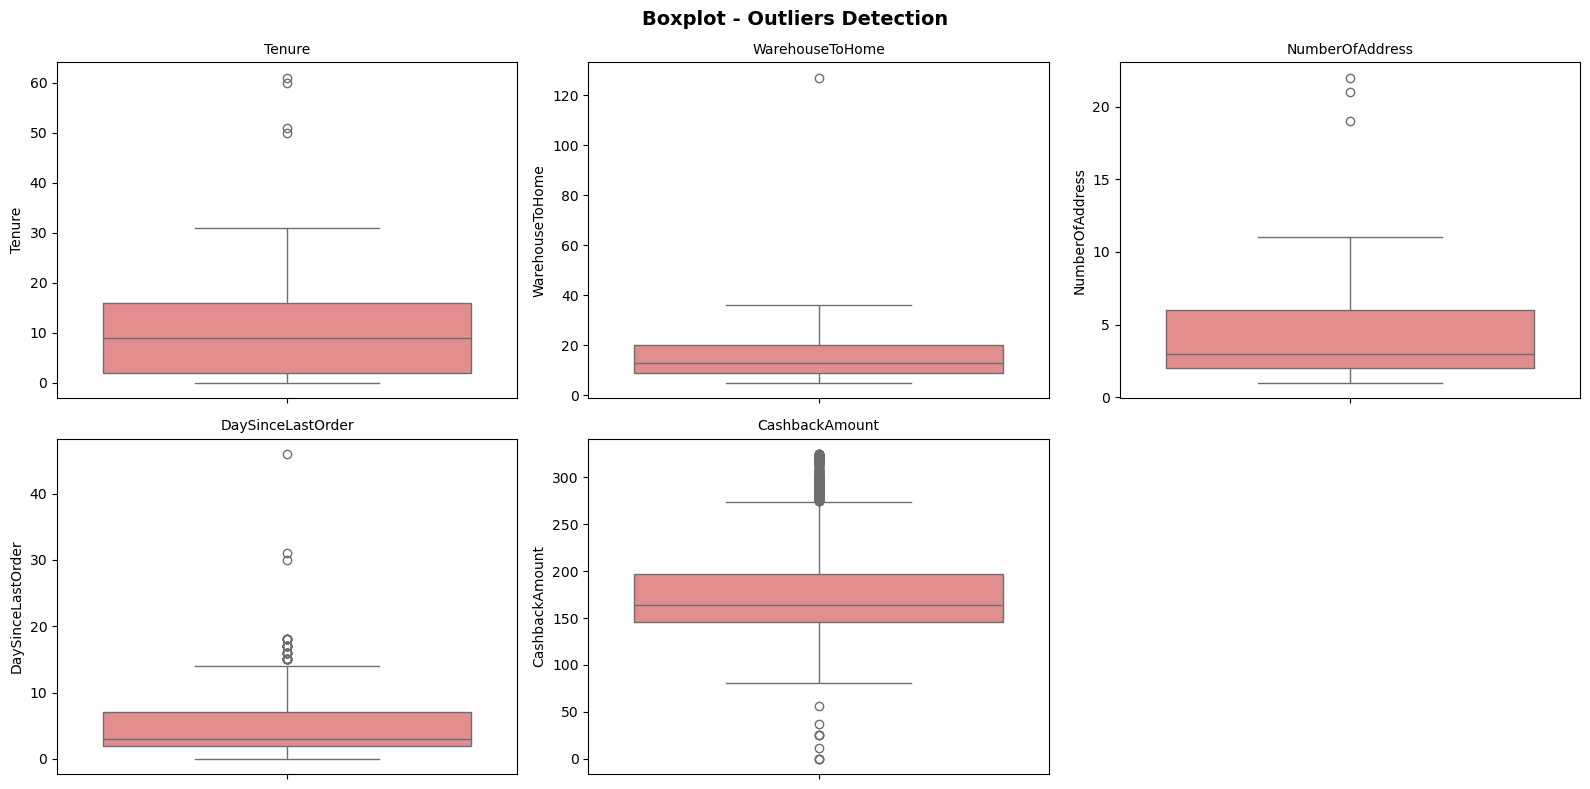

In [13]:
fig, axes = plt.subplots(2, 3, figsize=(16,8))
axes = axes.flatten()

for i, col in enumerate(num_cols_outlier):
    sns.boxplot(y=df_clean[col], ax=axes[i], color='lightcoral')
    axes[i].set_title(col, fontsize=10)

axes[-1].set_visible(False)
fig.suptitle('Boxplot - Outliers Detection', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

- Tenure → Mayoritas pelanggan punya masa aktif < 50 bulan, tapi ada outlier di atas 50 (pelanggan sangat lama).
- WarehouseToHome → Sebagian besar jarak < 120, tapi ada outlier ekstrem di atas 120 (mungkin data salah input atau kasus unik).
- NumberOfDeviceRegistered → Umumnya 2–4 perangkat, tapi ada outlier di 1 dan 6 (pelanggan dengan sangat sedikit atau sangat banyak perangkat).
- NumberOfAddress → Kebanyakan < 15 alamat, tapi ada outlier di atas 15 (pelanggan dengan banyak alamat terdaftar).
- DaySinceLastOrder → Mayoritas < 20 hari, tapi ada outlier di atas 20 (pelanggan lama tidak order).
- CashbackAmount → Sebagian besar cashback antara 50–250, tapi ada outlier tinggi > 250 dan rendah < 50.

In [14]:
print("Jumlah Outlier per Kolom (Metode IQR):")
print()
for col in num_cols_outlier:
    Q1 = df_clean[col].quantile(0.25)
    Q3 = df_clean[col].quantile(0.75)
    IQR = Q3 - Q1
    
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    
    outliers = (df_clean[col] < lower_bound) | (df_clean[col] > upper_bound)
    print(f"Jumlah outlier di kolom {col}: {outliers.sum()}")

Jumlah Outlier per Kolom (Metode IQR):

Jumlah outlier di kolom Tenure: 4
Jumlah outlier di kolom WarehouseToHome: 1
Jumlah outlier di kolom NumberOfAddress: 3
Jumlah outlier di kolom DaySinceLastOrder: 40
Jumlah outlier di kolom CashbackAmount: 253


**Outliers Handling** → akan ditangani saat preprocessing
- Alasan `NumberOfDeviceRegistered`, `DaySinceLastOrder` dan `CashbackAmount` prioritas utama → jumlahnya cukup besar, cukup untuk mendistorsi nilai rata-rata dan memengaruhi performa model tree-based maupun linear.

**Merapikan penamaan kategori yg mirip**

In [15]:
print("Nilai unik PreferedOrderCat SEBELUM:")
print(df_clean['PreferedOrderCat'].unique())

Nilai unik PreferedOrderCat SEBELUM:
['Laptop & Accessory' 'Mobile' 'Fashion' 'Others' 'Mobile Phone' 'Grocery']


In [16]:
df_clean['PreferedOrderCat'] = df_clean['PreferedOrderCat'].replace('Mobile', 'Mobile Phone')

print("Nilai unik PreferedOrderCat SESUDAH:")
print(df_clean['PreferedOrderCat'].unique())

Nilai unik PreferedOrderCat SESUDAH:
['Laptop & Accessory' 'Mobile Phone' 'Fashion' 'Others' 'Grocery']


In [17]:
data_desc = []
for i in df_clean.columns:
    n_unique = df_clean[i].nunique()
    sample_size = min(2, n_unique)
    data_desc.append([
        i,
        df_clean[i].dtypes,
        df_clean[i].isna().sum(),
        round(df_clean[i].isna().sum() / len(df_clean) * 100, 2),
        n_unique,
        df_clean[i].drop_duplicates().sample(sample_size).values
    ])

pd.DataFrame(data_desc, columns=[
    'Data Features',
    'Data Types',
    'Null',
    'Null Percentages',
    'Unique',
    'Unique Sample'
])

,Data Features,Data Types,Null,Null Percentages,Unique,Unique Sample
0,Tenure,float64,160,4.89,36,"[3.0, 23.0]"
1,WarehouseToHome,float64,135,4.13,33,"[6.0, 31.0]"
2,NumberOfDeviceRegistered,int64,0,0.00,6,"[2, 4]"
3,PreferedOrderCat,object,0,0.00,5,"[Others, Grocery]"
4,SatisfactionScore,int64,0,0.00,5,"[2, 4]"
5,MaritalStatus,object,0,0.00,3,"[Married, Single]"
6,NumberOfAddress,int64,0,0.00,14,"[6, 21]"
7,Complain,int64,0,0.00,2,"[0, 1]"
8,DaySinceLastOrder,float64,181,5.54,22,"[3.0, 12.0]"
9,CashbackAmount,float64,0,0.00,2335,"[149.55, 140.63]"


## C. Exploratory Data Analysis (EDA)

In [18]:
churn_counts = df_clean['Churn'].value_counts()
churn_pct = df_clean['Churn'].value_counts(normalize=True) * 100

churn_summary = pd.DataFrame({
    'Jumlah': churn_counts,
    'Persentase (%)': churn_pct.round(2)
})

churn_summary

,Jumlah,Persentase (%)
Churn,,
0,2736,83.67
1,534,16.33


Data **imbalanced** (tidak seimbang), **Churner hanya minoritas (16.3%)**. Maka perlu dilakukan SMOTE untuk menyeimbangkan data saat training.

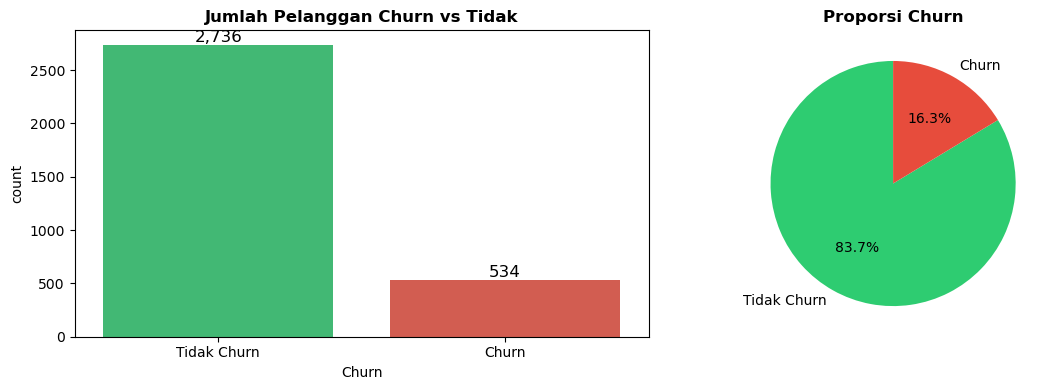

In [19]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Barplot
sns.countplot(x='Churn', data=df_clean, ax=axes[0],
              palette=['#2ecc71', '#e74c3c'])
axes[0].set_title('Jumlah Pelanggan Churn vs Tidak', fontweight='bold')
axes[0].set_xticklabels(['Tidak Churn', 'Churn'])
for p in axes[0].patches:
    axes[0].annotate(f'{int(p.get_height()):,}', 
                     (p.get_x() + p.get_width()/2, p.get_height()),
                     ha='center', va='bottom', fontsize=12)

# Pie chart
axes[1].pie(churn_counts, labels=['Tidak Churn', 'Churn'],
            autopct='%1.1f%%', colors=['#2ecc71', '#e74c3c'],
            startangle=90)
axes[1].set_title('Proporsi Churn', fontweight='bold')

plt.tight_layout()
plt.show()

In [20]:
num_cols = ['Tenure', 'WarehouseToHome', 'NumberOfDeviceRegistered', 'SatisfactionScore', 'NumberOfAddress', 'Complain', 'DaySinceLastOrder', 'CashbackAmount']

num_cols = df_clean.select_dtypes(include=np.number).columns.tolist()

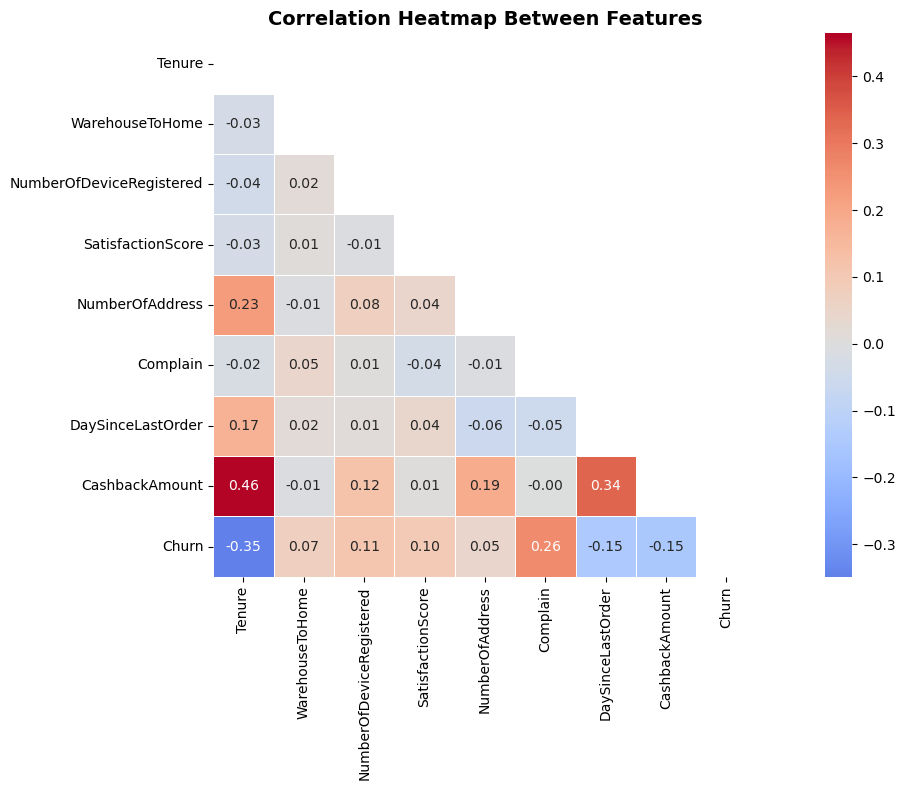


Feature Correlation to Churn (sorted):
Tenure                     -0.349
Complain                    0.262
CashbackAmount             -0.151
DaySinceLastOrder          -0.148
NumberOfDeviceRegistered    0.110
SatisfactionScore           0.098
WarehouseToHome             0.074
NumberOfAddress             0.046
Name: Churn, dtype: float64


In [21]:
plt.figure(figsize=(14, 8))
corr_matrix = df_clean[num_cols].corr()

mask = np.triu(np.ones_like(corr_matrix, dtype=bool))

sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='coolwarm',
            mask=mask, center=0, square=True, linewidths=0.5)
plt.title('Correlation Heatmap Between Features', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

# Tampilkan korelasi terhadap Churn saja
print("\nFeature Correlation to Churn (sorted):")
korelasi_churn = corr_matrix['Churn'].drop('Churn').sort_values(key=abs, ascending=False)
print(korelasi_churn.round(3))

Berdasarkan korelasi, Urutan fitur paling penting untuk churn adalah:
1. Tenure (-0.336): Memiliki korelasi negatif yang cukup kuat. Artinya, **semakin lama masa berlangganan (Tenure) seseorang, semakin kecil kemungkinan mereka untuk Churn** → Pelanggan setia jarang kabur.
2. Complain (0.262): Korelasi positif. **Semakin banyak komplain, semakin besar kemungkinan mereka untuk Churn.**
3. CashbackAmount (-0.151): Korelasi negatif. **Semakin baru pelanggan belanja (angka hari sedikit), kecenderungan Churn sedikit berkurang, atau sebaliknya.**
4. DaySinceLastOrder (-0.149): Korelasi negatif. **Semakin baru pelanggan belanja (angka hari sedikit), kecenderungan Churn sedikit berkurang, atau sebaliknya.**
5. NumberOfDeviceRegistered (0.110): Korelasi positif. **Semakin banyak jumlah perangkat yg terdaftar, semakin besar kemungkinan mereka untuk Churn.**

**Feature Engineering**

1. NewCustomer : Apakah pelanggan baru (Tenure <= 3 bulan)
   - Hipotesis : pelanggan baru lebih beresiko churn (belum loyal)
2. HighDistance: apakah jarak pengiriman jauh? (di atas median)
   - Hipotesis: jarak jauh bisa meningkatkan ketidakpuasan
3. LowCashback : cashback rendah (di bawah Q1)
   - Hipotesis: cashback rendah = insentif kurang = lebih mudah churn

In [49]:
# df_clean['NewCustomer'] = (df_clean['Tenure'] <= 3).astype(int)
# df_clean['HighDistance'] = (df_clean['WarehouseToHome'] > df_clean['WarehouseToHome'].median()).astype(int)
# df_clean['LowCashback'] = (df_clean['CashbackAmount'] < df_clean['CashbackAmount'].quantile(0.25)).astype(int)

# print("Feature engineering selesai.")
# print("Fitur baru yang ditambahkan:")
# print(" - NewCustomer (Tenure <= 3)")
# print(" - HighDistance (jarak > median)")
# print(" - LowCashback (cashback < Q1)")

Feature engineering selesai.
Fitur baru yang ditambahkan:
 - NewCustomer (Tenure <= 3)
 - HighDistance (jarak > median)
 - LowCashback (cashback < Q1)


Kemudian cek korelasi fitur terhadap churn lagi.

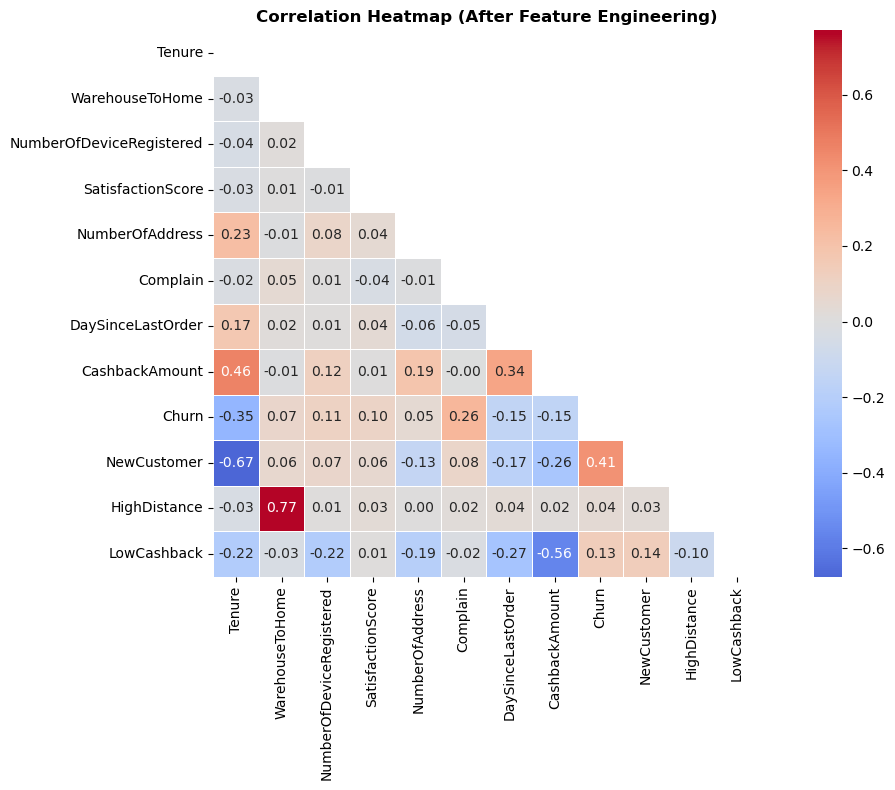

In [50]:
# plt.figure(figsize=(12, 8))
# corr_matrix = df_clean.select_dtypes(include=np.number).corr()
# mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
# sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='coolwarm',
#             mask=mask, center=0, square=True, linewidths=0.5)
# plt.title('Correlation Heatmap (After Feature Engineering)', fontweight='bold')
# plt.tight_layout()
# plt.show()

Berdasarkan heatmap korelasi - after feature engineering:
- **NewCustomer (0.41)**: Memiliki korelasi positif tertinggi. Maksudnya, pelanggan yang dikategorikan sebagai **"New Customer" memiliki kecenderungan lebih tinggi untuk Churn (berhenti berlangganan).**
- **LowCashback (0.13)**: Korelasi positif. **LowCashback memiliki kemungkinan kecenderungan tinggi untuk Churn (berhenti berlangganan).**

Tetapi:
- HighDistance redundant dengan WarehouseToHome (0.77) dan perlu di hapus (drop).
   
→ Jadi fitur yg bertambah adalah kolom `NewCustomer` dan `LowCashback`.

In [51]:
# df_clean = df_clean.drop('HighDistance', axis=1)

## D. Analytics (Machine Learning; Algorithm & Evaluation Metrics)

In [52]:
## after FE
df_clean.head()

,Tenure,WarehouseToHome,NumberOfDeviceRegistered,PreferedOrderCat,SatisfactionScore,MaritalStatus,NumberOfAddress,Complain,DaySinceLastOrder,CashbackAmount,Churn,NewCustomer,LowCashback
0,15.0,29.0,4,Laptop & Accessory,3,Single,2,0,7.0,143.32,0,0,1
1,7.0,25.0,4,Mobile Phone,1,Married,2,0,7.0,129.29,0,0,1
2,27.0,13.0,3,Laptop & Accessory,1,Married,5,0,7.0,168.54,0,0,0
3,20.0,25.0,4,Fashion,3,Divorced,7,0,NaN,230.27,0,0,0
4,30.0,15.0,4,Others,4,Single,8,0,8.0,322.17,0,0,0


In [26]:
# df_clean.head()

,Tenure,WarehouseToHome,NumberOfDeviceRegistered,PreferedOrderCat,SatisfactionScore,MaritalStatus,NumberOfAddress,Complain,DaySinceLastOrder,CashbackAmount,Churn
0,15.0,29.0,4,Laptop & Accessory,3,Single,2,0,7.0,143.32,0
1,7.0,25.0,4,Mobile Phone,1,Married,2,0,7.0,129.29,0
2,27.0,13.0,3,Laptop & Accessory,1,Married,5,0,7.0,168.54,0
3,20.0,25.0,4,Fashion,3,Divorced,7,0,NaN,230.27,0
4,30.0,15.0,4,Others,4,Single,8,0,8.0,322.17,0


# LANJUT MODELING — BEFORE FE (model final)

In [72]:
# Drop kolom FE dari df_clean
df_clean = df_clean.drop(
    columns=['NewCustomer','LowCashback'], errors='ignore')

**Target dan Features**

In [73]:
X = df_clean.drop('Churn', axis=1) ## Churn adalah kolom yg ingin diprediksi
y = df_clean['Churn']

**Splitting Data**

In [74]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

**Preprocessing dan Pipeline** → pada data train.
- Untuk handling *missing value*.
- Untuk *scaling kolom numerikal* dan *encode kolom kategorikal*.

In [75]:
## Before FE
X_train.shape

(2616, 10)

In [55]:
# ## After FE
# X_train.shape

(2616, 12)

In [76]:
## Before FE -FINAL
X_train.head()

,Tenure,WarehouseToHome,NumberOfDeviceRegistered,PreferedOrderCat,SatisfactionScore,MaritalStatus,NumberOfAddress,Complain,DaySinceLastOrder,CashbackAmount
3504,8.0,7.0,5,Mobile Phone,4,Divorced,7,0,3.0,157.94
622,22.0,14.0,4,Grocery,4,Married,7,0,NaN,231.20
2813,10.0,16.0,3,Mobile Phone,5,Divorced,7,0,3.0,134.52
792,8.0,12.0,5,Fashion,5,Single,4,0,9.0,241.31
1968,15.0,6.0,3,Laptop & Accessory,3,Married,2,0,6.0,149.07


In [56]:
# # after FE
# X_train.head()

,Tenure,WarehouseToHome,NumberOfDeviceRegistered,PreferedOrderCat,SatisfactionScore,MaritalStatus,NumberOfAddress,Complain,DaySinceLastOrder,CashbackAmount,NewCustomer,LowCashback
3504,8.0,7.0,5,Mobile Phone,4,Divorced,7,0,3.0,157.94,0,0
622,22.0,14.0,4,Grocery,4,Married,7,0,NaN,231.20,0,0
2813,10.0,16.0,3,Mobile Phone,5,Divorced,7,0,3.0,134.52,0,1
792,8.0,12.0,5,Fashion,5,Single,4,0,9.0,241.31,0,0
1968,15.0,6.0,3,Laptop & Accessory,3,Married,2,0,6.0,149.07,0,0


In [77]:
# before feature engineering
num_columns = ['Tenure', 'WarehouseToHome', 'NumberOfDeviceRegistered', 'SatisfactionScore', 'NumberOfAddress', 'Complain',
           'DaySinceLastOrder', 'CashbackAmount']
cat_columns = ['PreferedOrderCat', 'MaritalStatus']

### Catatan: NewCustomer dan LowCashback (Feature Engineering) tidak diaktifkan
### karena terbukti menurunkan performa Random Forest (Recall: 0.822 → 0.757)
### Model final menggunakan Before FE — lihat perbandingan di section EDA

In [57]:
# # after feature engineering
# num_columns = ['Tenure', 'WarehouseToHome', 'NumberOfDeviceRegistered', 'SatisfactionScore', 'NumberOfAddress', 'Complain',
#            'DaySinceLastOrder', 'CashbackAmount', 'NewCustomer', 'LowCashback']
# cat_columns = ['PreferedOrderCat', 'MaritalStatus']

In [78]:
num_pipeline = Pipeline([
    ('imputer', SimpleImputer (strategy= 'median')), ## isi missing value dg median
    ('scaler', RobustScaler()) ## Untuk Scaling
])

cat_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='most_frequent')), ## Isi missing value menggunakan most_frequent = Mode = Modus karena data kategorikal
    ('encoder', OneHotEncoder ()) ## untuk Encoding ==> OneHotEncoding karena general
])

- Imputer → mengisi missing value kolom numerikal dengan median dan kolom kategorikal dengan most frequent/modus.
- Scaler untuk kolom numerik dengan RobustScaler
- Encoder untuk kolom kategorikal dengan OneHotEncoding

In [79]:
preprocessor = ColumnTransformer([
    ('numeric', num_pipeline, num_columns),
    ('categoric', cat_pipeline, cat_columns)
], remainder='passthrough')

In [80]:
X_train_processed = preprocessor.fit_transform(X_train) # fit + transform di train
X_test_processed  = preprocessor.transform(X_test)        # hanya transform di test

**Imbalanced Data Handling**
- Dengan SMOTE, hanya dilakukan pada TRAIN SET.
- Masalah: hanya 16.3% data adalah churner. Model akan selalu prediksi 'tidak churn' dan tetap akurasi 83%. Ini tidak berguna.
- SMOTE → Membuat data SINTETIS untuk kelas minoritas (churner) sampai seimbang.

Alasan:
- Menyeimbangkan kelas → tanpa balancing, **model cenderung selalu menebak “tidak churn”** *karena mayoritas data memang tidak churn*. Akurasinya tinggi (misalnya 83%), tapi tidak berguna karena recall untuk churn sangat rendah.
- Menghindari overfitting → dibanding oversampling acak (menggandakan data minoritas), SMOTE membuat data sintetis baru dengan interpolasi antar titik minoritas. Ini memberi variasi lebih realistis.
- Meningkatkan recall → model jadi lebih sensitif terhadap kelas minoritas (churn), sehingga lebih banyak kasus churn yang bisa terdeteksi.

In [81]:
smote = SMOTE(random_state=42)
X_train_res, y_train_res = smote.fit_resample(X_train_processed, y_train)

In [82]:
print(f"Sebelum SMOTE: {X_train_processed.shape[0]} baris")
print(f"Sesudah SMOTE: {X_train_res.shape[0]} baris")

Sebelum SMOTE: 2616 baris
Sesudah SMOTE: 4378 baris


In [83]:
print(f"Total df_clean: {len(df_clean)}")
print(f"Train: {len(X_train)}, Test: {len(X_test)}")
# Harusnya: Train ≈ 80%, Test ≈ 20%

Total df_clean: 3270
Train: 2616, Test: 654


In [84]:
print("Jumlah sampel sebelum SMOTE:")
print(y_train.value_counts())

print("Jumlah sampel sesudah SMOTE:")
print(pd.Series(y_train_res).value_counts())

Jumlah sampel sebelum SMOTE:
Churn
0    2189
1     427
Name: count, dtype: int64
Jumlah sampel sesudah SMOTE:
Churn
0    2189
1    2189
Name: count, dtype: int64


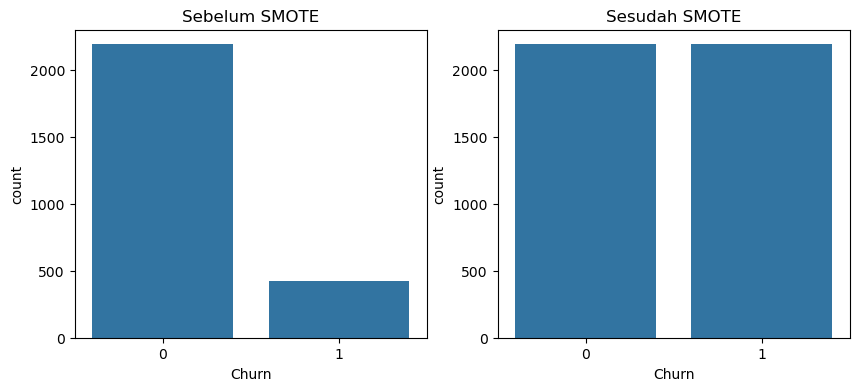

In [85]:
plt.figure(figsize=(10, 4))

plt.subplot(1, 2, 1)
sns.countplot(x=y_train)
plt.title('Sebelum SMOTE')

plt.subplot(1, 2, 2)
sns.countplot(x=y_train_res)
plt.title('Sesudah SMOTE')

plt.show()

## ================================================================================

In [86]:
# Data yang digunakan untuk training dan evaluasi:
# - X_train_res, y_train_res → hasil SMOTE (untuk training model)
# - X_test_processed, y_test → data test asli (untuk evaluasi model)

print(f'Shape X_train_res    : {X_train_res.shape}')
print(f'Shape X_test_processed: {X_test_processed.shape}')

Shape X_train_res    : (4378, 16)
Shape X_test_processed: (654, 16)


**Model Algorithm**

In [87]:
models = [
    ['Logistic Regression', LogisticRegression(max_iter=1000, random_state=42)],
    ['K-Neighbors', KNeighborsClassifier()],
    ['Decision Tree', DecisionTreeClassifier(random_state=42)],
    ['Random Forest', RandomForestClassifier(random_state=42, n_estimators=100)],
]

**Perbandingan**

In [88]:
model_results        = []
train_test_comparison = []

for name, model in models:
    # ── Training ──
    model.fit(X_train_res, y_train_res)  # fit di SMOTE data

    # ── Train score ── (predict di data yang sama saat fit)
    y_pred_train  = model.predict(X_train_res)
    recall_train  = recall_score(y_train_res, y_pred_train)
    f1_train      = f1_score(y_train_res, y_pred_train)
    acc_train     = accuracy_score(y_train_res, y_pred_train)
    prec_train    = precision_score(y_train_res, y_pred_train)

    # ── Test score ──
    y_pred        = model.predict(X_test_processed)
    y_prob        = model.predict_proba(X_test_processed)[:,1]
    recall_test   = recall_score(y_test, y_pred)
    f1_test       = f1_score(y_test, y_pred)
    acc_test      = accuracy_score(y_test, y_pred)
    prec_test     = precision_score(y_test, y_pred)
    roc_auc       = roc_auc_score(y_test, y_prob)

    # ── Simpan untuk tabel utama ──
    model_results.append([
        name, acc_test, prec_test,
        recall_test, f1_test, roc_auc
    ])

    # ── Simpan untuk cek overfit ──
    train_test_comparison.append([
        name,
        round(acc_train, 3),
        round(prec_train, 3),
        round(recall_train, 3),
        round(recall_test, 3),
        round(recall_train - recall_test, 3),
        round(f1_train, 3),
        round(f1_test, 3),
        round(roc_auc, 3)
    ])

# ── Tabel overfit check ──
df_overfit = pd.DataFrame(train_test_comparison, columns=[
    'Model',
    'Accuracy Train',
    'Precision Train',
    'Recall Train',
    'Recall Test',
    'Gap Recall',
    'F1 Train',
    'F1 Test',
    'ROC-AUC'
])

df_overfit['Status'] = df_overfit['Gap Recall'].apply(
    lambda g: '✅ Good Fit' if abs(g) <= 0.05
    else ('⚠️ Overfit' if g > 0.05 else '⚠️ Underfit')
)

# Tampilkan hanya Recall & F1 Train vs Test
df_display = df_overfit[[
    'Model',
    'Recall Train', 'Recall Test', 'Gap Recall',
    'F1 Train', 'F1 Test',
    'Status'
]].sort_values(by='Recall Test', ascending=False)

print("=== Train vs Test (Sorted by Recall Test) ===")
print(df_display.to_string(index=False))

=== Train vs Test (Sorted by Recall Test) ===
              Model  Recall Train  Recall Test  Gap Recall  F1 Train  F1 Test      Status
Logistic Regression         0.824        0.907      -0.082     0.806    0.581 ⚠️ Underfit
      Random Forest         1.000        0.822       0.178     1.000    0.775  ⚠️ Overfit
        K-Neighbors         0.994        0.804       0.190     0.937    0.581  ⚠️ Overfit
      Decision Tree         1.000        0.673       0.327     1.000    0.637  ⚠️ Overfit


**Results - Evaluation**

In [89]:
df_results = pd.DataFrame(model_results, columns=[
    'Model Name','Accuracy','Precision','Recall','F1','ROC-AUC'
]).round(3)

print(df_results.sort_values(by='Recall', ascending=False))

            Model Name  Accuracy  Precision  Recall     F1  ROC-AUC
0  Logistic Regression     0.786      0.427   0.907  0.581    0.918
3        Random Forest     0.922      0.733   0.822  0.775    0.957
1          K-Neighbors     0.810      0.455   0.804  0.581    0.868
2        Decision Tree     0.875      0.605   0.673  0.637    0.793


Interpretasi :
1. Logistic Regression
    - Recall sangat tinggi (90.7%) → hampir semua churn terdeteksi.
    - Precision rendah (42.7%) → banyak false positive (pelanggan dianggap churn padahal tidak).
    - Cocok jika tujuan bisnis adalah menangkap sebanyak mungkin churner, meskipun ada “false alarm”.

2. Random Forest
    - Accuracy tertinggi (92.2%), precision tinggi (73.3%), recall juga bagus (82.2%).
    - F1-score dan ROC-AUC paling tinggi → model paling seimbang dan kuat.
    - Cocok untuk prediksi churn yang lebih akurat dan stabil, dengan keseimbangan antara mendeteksi churn dan menghindari false alarm.

3. K-Neighbors
    - Recall cukup tinggi (80.4%), tapi precision rendah (45.5%).
    - F1-score rendah → kurang efisien dibanding Random Forest.
    - Bisa dipakai, tapi performanya tidak sebaik Random Forest.

4. Decision Tree
    - Precision lumayan (60.5%), tapi recall rendah (67.3%).
    - Model cenderung lebih sederhana, tapi kurang optimal dibanding Random Forest.

In [48]:
# ## hasil model sebelum FE (NewCustomer dan LowCashback)
# results_before = df_results.copy()
# results_before['Version'] = 'Before FE'

In [70]:
# ## hasil model setelah FE (NewCustomer dan LowCashback) dan retrain
# results_after = df_results.copy()
# results_after['Version'] = 'After FE'

In [71]:
# # PERBANDINGAN
# comparison = pd.concat([results_before, results_after])
# print(comparison[['Version','Model Name','Recall','F1','ROC-AUC']])

     Version           Model Name  Recall     F1  ROC-AUC
0  Before FE  Logistic Regression   0.907  0.581    0.918
1  Before FE          K-Neighbors   0.804  0.581    0.868
2  Before FE        Decision Tree   0.673  0.637    0.793
3  Before FE        Random Forest   0.822  0.775    0.957
0   After FE  Logistic Regression   0.907  0.606    0.921
1   After FE          K-Neighbors   0.804  0.591    0.892
2   After FE        Decision Tree   0.748  0.699    0.835
3   After FE        Random Forest   0.757  0.743    0.956


**Model terbaik saat ini (sebelum *Hypeparameter Tuning*)**

Before Feature Engineering (NewCustomer dan LowCashback)
> - Adalah **Random Forest** → paling seimbang, akurasi tinggi, precision & recall sama-sama bagus, ROC-AUC tertinggi.
> - **Logistic Regression** unggul di recall → cocok jika bisnis lebih peduli mendeteksi semua churner (walau banyak false alarm).
> - KNN & Decision Tree performanya lebih rendah, bisa dijadikan baseline tapi bukan pilihan utama.

After Feature Engineering (NewCustomer dan LowCashback)
> - Adalah **Logistic Regression** → Recall tetap sama (0.907), tapi F1 naik 0.581 → 0.606 dan ROC-AUC naik tipis. Artinya fitur baru membantu LR lebih presisi, tanpa mengorbankan kemampuan deteksi churn.
> - Random Forest → recall 75.7%
> - K-Neighbors → naik cukup signifikan. F1 naik 0.581 → 0.591, ROC-AUC naik 0.868 → 0.892. KNN sensitif terhadap representasi fitur, jadi fitur biner baru membantu menghitung jarak antar pelanggan lebih baik.
> - Decision Tree — naik paling besar proporsinya. Recall naik 0.673 → 0.748, F1 naik 0.637 → 0.699. Decision Tree memang diuntungkan fitur biner karena split-nya jadi lebih mudah dan langsung.

**Model FINAL yg akan di pakai untuk Hyperparameter Tuning**
- adalah **sebelum Feature Engineering (tanpa NewCustomer dan LowCashback)**.
- Alasan → **Random Forest Before FE** lebih unggul di semua metrik yang penting karena sudah mampu menangkap pola sendiri.
  
  - Random Forest Before FE:  Recall 0.822 | F1 0.775 | ROC-AUC 0.957
  - Random Forest After FE:   Recall 0.757 | F1 0.743 | ROC-AUC 0.956

- FE justru menurunkan performa Random Forest — menambah multikolinearitas dengan Tenure dan model ini sudah bisa menemukan pola sendiri tanpa perlu fitur biner tambahan.

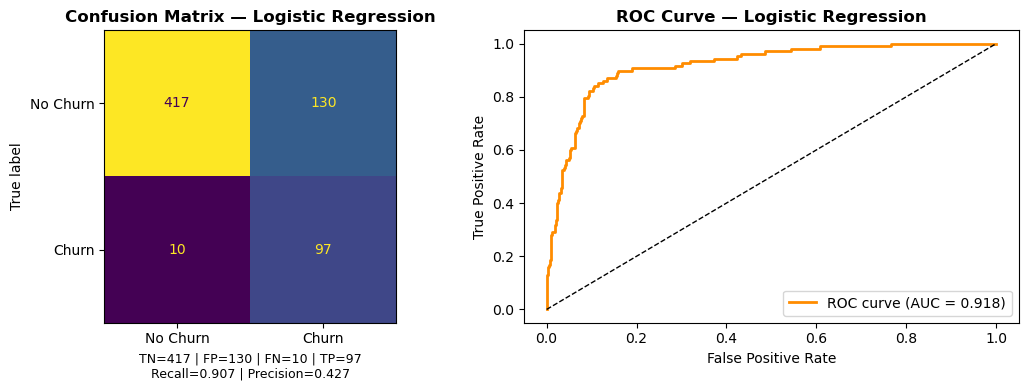

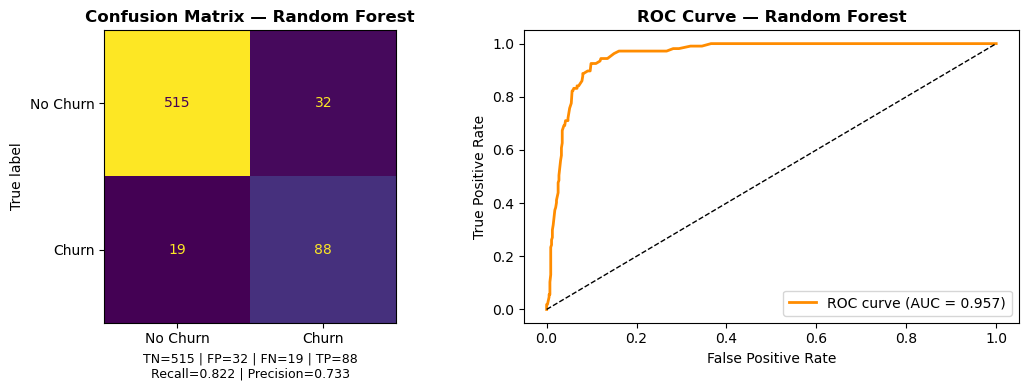

In [90]:
## Visualisasi

def plot_confusion_roc(model_name, y_pred, y_prob, y_test):
    fig, axes = plt.subplots(1, 2, figsize=(11, 4))
    
    # Confusion Matrix
    cm = confusion_matrix(y_test, y_pred)
    ConfusionMatrixDisplay(cm, display_labels=['No Churn','Churn'])\
        .plot(ax=axes[0], colorbar=False)
    tn, fp, fn, tp = cm.ravel()
    axes[0].set_title(f'Confusion Matrix — {model_name}', fontweight='bold')
    axes[0].set_xlabel(
        f'TN={tn} | FP={fp} | FN={fn} | TP={tp}\n'
        f'Recall={tp/(tp+fn):.3f} | Precision={tp/(tp+fp):.3f}',
        fontsize=9
    )
    
    # ROC Curve
    fpr, tpr, _ = roc_curve(y_test, y_prob)
    roc_auc_val = auc(fpr, tpr)
    axes[1].plot(fpr, tpr, color='darkorange', lw=2,
                 label=f'ROC curve (AUC = {roc_auc_val:.3f})')
    axes[1].plot([0,1],[0,1], 'k--', lw=1)
    axes[1].set_title(f'ROC Curve — {model_name}', fontweight='bold')
    axes[1].set_xlabel('False Positive Rate')
    axes[1].set_ylabel('True Positive Rate')
    axes[1].legend(loc='lower right')

    plt.tight_layout()
    plt.show()

# Jalankan untuk LR dan RF baseline
# Ambil prediksi dari model yang sudah dilatih di loop sebelumnya
for name, model in models:
    if name in ['Logistic Regression', 'Random Forest']:
        y_pred_vis = model.predict(X_test_processed)
        y_prob_vis = model.predict_proba(X_test_processed)[:,1]
        plot_confusion_roc(name, y_pred_vis, y_prob_vis, y_test)

Interpretasi:
1. Logistic Regression 
    - TN (417) → pelanggan tidak churn yang benar terdeteksi.
    - FP (130) → pelanggan tidak churn tapi diprediksi churn (promo salah sasaran).
    - FN (10) → pelanggan churn tapi tidak terdeteksi (pelanggan hilang).
    - TP (97) → pelanggan churn yang benar terdeteksi.
    - ROC–AUC = 0.918 → model cukup kuat membedakan churn vs tidak churn.
      
    - Maksudnya: Logistic Regression lumayan akurat, tapi masih banyak false positive (promo ke pelanggan yang sebenarnya loyal).

2. Random Forest 
    - TN (515) → pelanggan tidak churn yang benar terdeteksi.
    - FP (32) → jauh lebih sedikit promo salah sasaran dibanding Logistic Regression.
    - FN (19) → ada churner yang lolos tidak terdeteksi.
    - TP (88) → churner yang benar terdeteksi.
    - ROC–AUC = 0.957 → lebih tinggi dari Logistic Regression, menunjukkan diskriminasi lebih baik.
      
    - Maksudnya: Random Forest lebih akurat, lebih sedikit salah sasaran, meski ada sedikit peningkatan false negative (beberapa churner tidak terdeteksi).

**Strategi bisnis:**

- Jika ingin hemat biaya promo → Random Forest lebih cocok (FP rendah).
- Jika ingin menangkap sebanyak mungkin churner → Logistic Regression bisa dipertimbangkan karena FN lebih rendah.

- Kombinasi keduanya bisa dipakai: Random Forest untuk sistem otomatis, Logistic Regression untuk insight ke stakeholder.

**Hyperparameter Tuning** (pada Train set)

→ untuk model **Logistic Regression** dan **Random Forest.**

- Dengan RandomizedSearchCV, mencoba kombinasi parameter secara acak
- Tuning membantu menemukan parameter yang lebih sesuai dengan dataset churn.
- Untuk Logistic Regression → tuning regularisasi (C, penalty, solver).
- Untuk Random Forest → tuning jumlah pohon, kedalaman, jumlah fitur, dan aturan split.
- Tujuannya: menemukan parameter optimal yang meningkatkan ROC-AUC, Recall, dan F1-score sehingga model lebih kuat mendeteksi churn.

In [91]:
param_dist_lr = {
    'C': np.logspace(-3, 3, 50),
    'penalty': ['l1', 'l2'],
    'solver': ['liblinear', 'saga']
}

random_lr = RandomizedSearchCV(
    LogisticRegression(max_iter=1000, random_state=42),
    param_distributions=param_dist_lr,
    n_iter=20,    # jumlah kombinasi acak yang dicoba
    cv=5,
    scoring={
        'recall': 'recall',
        'precision': 'precision',
        'f1': 'f1',
        'roc_auc': 'roc_auc'
    },
    refit='recall',        # model terbaik dipilih berdasarkan Recall
    return_train_score=True,
    random_state=42,
    n_jobs=-1
)

random_lr.fit(X_train_res, y_train_res)

print("Best Logistic Regression params :", random_lr.best_params_)
print("Best Recall (CV):", random_lr.best_score_.round(3))

Best Logistic Regression params : {'solver': 'liblinear', 'penalty': 'l2', 'C': np.float64(0.0071968567300115215)}
Best Recall (CV): 0.828


In [92]:
# Parameter Random Forest
param_dist_rf = {
    'n_estimators': np.arange(100, 800, 50),  # jumlah pohon
    'max_depth': [None, 5, 10, 15, 20, 30],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4],
    'max_features': ['sqrt', 'log2'],
    'class_weight': ['balanced', None]
}

random_rf = RandomizedSearchCV(
    RandomForestClassifier(random_state=42),
    param_distributions=param_dist_rf,
    n_iter=50,
    cv=5,
    scoring={
        'recall': 'recall',
        'precision': 'precision',
        'f1': 'f1',
        'roc_auc': 'roc_auc'
    },
    refit='recall',           # model terbaik dipilih berdasarkan Recall
    return_train_score=True,
    random_state=42,
    n_jobs=-1                 # pakai semua core CPU → lebih cepat
)

random_rf.fit(X_train_res, y_train_res)

print("Best RF params  :", random_rf.best_params_)
print("Best Recall (CV):", round(random_rf.best_score_, 3))

Best RF params  : {'n_estimators': np.int64(350), 'min_samples_split': 2, 'min_samples_leaf': 1, 'max_features': 'log2', 'max_depth': 15, 'class_weight': 'balanced'}
Best Recall (CV): 0.954


**Evaluasi model setelah tuning** (pada Test set)

In [93]:
# Evaluasi Logistic Regression setelah tuning
best_lr = random_lr.best_estimator_
y_pred_lr_tuned = best_lr.predict(X_test_processed)
y_prob_lr_tuned = best_lr.predict_proba(X_test_processed)[:,1]

# Evaluasi Random Forest setelah tuning
best_rf = random_rf.best_estimator_
y_pred_rf_tuned = best_rf.predict(X_test_processed)
y_prob_rf_tuned = best_rf.predict_proba(X_test_processed)[:,1]

# Tabel hasil tuning
tuning_results = pd.DataFrame([
    ['LR (Tuned)',
     accuracy_score(y_test, y_pred_lr_tuned),
     precision_score(y_test, y_pred_lr_tuned),
     recall_score(y_test, y_pred_lr_tuned),
     f1_score(y_test, y_pred_lr_tuned),
     roc_auc_score(y_test, y_prob_lr_tuned)],
    ['RF (Tuned)',
     accuracy_score(y_test, y_pred_rf_tuned),
     precision_score(y_test, y_pred_rf_tuned),
     recall_score(y_test, y_pred_rf_tuned),
     f1_score(y_test, y_pred_rf_tuned),
     roc_auc_score(y_test, y_prob_rf_tuned)],
], columns=['Model Name','Accuracy','Precision','Recall','F1','ROC-AUC']).round(3)

# Gabungkan dengan baseline untuk perbandingan
baseline = pd.DataFrame(model_results,
    columns=['Model Name','Accuracy','Precision','Recall','F1','ROC-AUC']
).round(3)

# Filter hanya LR dan RF baseline
baseline_lr_rf = baseline[baseline['Model Name'].isin(['Logistic Regression','Random Forest'])].copy()
baseline_lr_rf['Model Name'] = baseline_lr_rf['Model Name'].replace({
    'Logistic Regression': 'LR (Baseline)',
    'Random Forest': 'RF (Baseline)'
})

# Tampilkan perbandingan
comparison = pd.concat([baseline_lr_rf, tuning_results], ignore_index=True)
print("=== Baseline vs Setelah Tuning ===")
print(comparison.to_string(index=False))

=== Baseline vs Setelah Tuning ===
   Model Name  Accuracy  Precision  Recall    F1  ROC-AUC
LR (Baseline)     0.786      0.427   0.907 0.581    0.918
RF (Baseline)     0.922      0.733   0.822 0.775    0.957
   LR (Tuned)     0.746      0.384   0.916 0.541    0.917
   RF (Tuned)     0.924      0.744   0.813 0.777    0.959


- Random Forest Tuned → lebih seimbang dan akurat secara keseluruhan, meski Recall sedikit turun dari baseline.
- Logistic Regression Tuned → tuning berhasil menaikkan Recall, tapi model jadi lebih agresif memprediksi churn — lebih banyak false positive (pelanggan tidak churn diprediksi churn).

>**Random Forest Tuned sebagai model final** — karena:
- ROC-AUC tertinggi (0.959) → diskriminasi terbaik
- F1 tertinggi (0.777) → paling seimbang
- Recall 0.813 sudah melampaui target minimum 0.80 yang ditetapkan di business problem
- Precision 0.744 → promo tidak terlalu banyak salah sasaran

>LR Tuned tetap dicantumkan sebagai alternatif jika suatu saat bisnis memutuskan prioritas bergeser ke "tangkap semua churner apapun biayanya".

**Confusion Matrix setelah tuning**

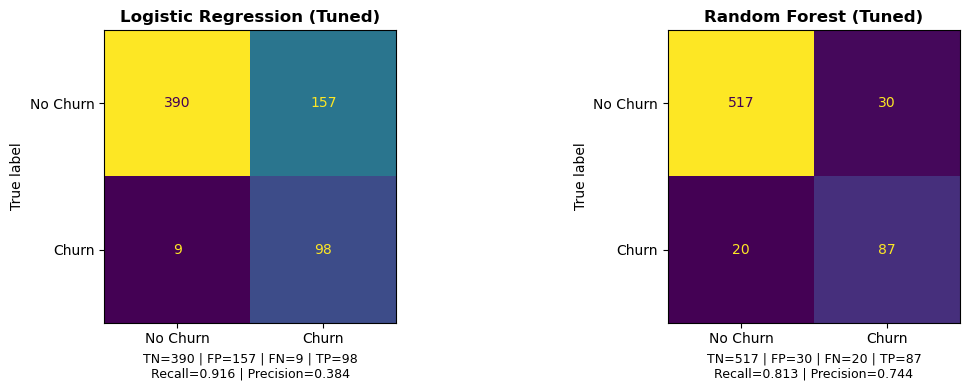

In [94]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

for ax, y_pred, title in zip(
    axes,
    [y_pred_lr_tuned, y_pred_rf_tuned],
    ['Logistic Regression (Tuned)', 'Random Forest (Tuned)']
):
    cm = confusion_matrix(y_test, y_pred)
    ConfusionMatrixDisplay(cm, display_labels=['No Churn','Churn']).plot(ax=ax, colorbar=False)
    ax.set_title(title, fontweight='bold')

    # Tambahkan anotasi TN, FP, FN, TP
    tn, fp, fn, tp = cm.ravel()
    ax.set_xlabel(
        f"TN={tn} | FP={fp} | FN={fn} | TP={tp}\n"
        f"Recall={tp/(tp+fn):.3f} | Precision={tp/(tp+fp):.3f}",
        fontsize=9
    )

plt.tight_layout()
plt.show()

LR (Tuned):
- TP  = churner terdeteksi dengan benar → lebih banyak dari RF
- FP  = pelanggan loyal diprediksi churn → lebih banyak (promo boros)
- FN  = churner tidak terdeteksi → lebih sedikit (bagus)

RF (Tuned):
- TP  = churner terdeteksi dengan benar
- FP  = jauh lebih sedikit dari LR → promo lebih tepat sasaran
- FN  = sedikit lebih banyak dari LR → ada churner yang lolos

Kesimpulan:
- LR Tuned → cocok jika prioritas: tangkap semua churner (Recall tinggi)
- RF Tuned → cocok jika prioritas: seimbang antara deteksi & efisiensi promo

**Precision-Recall Curve**

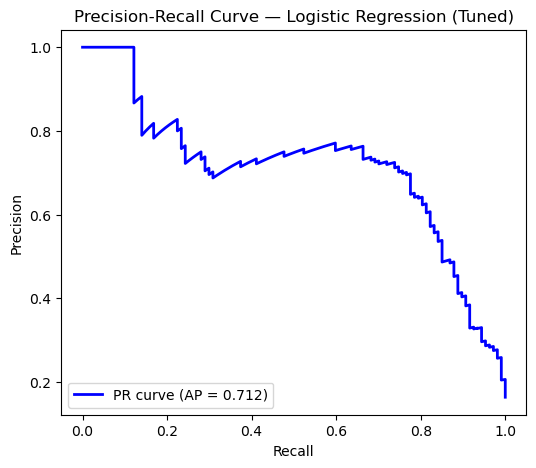

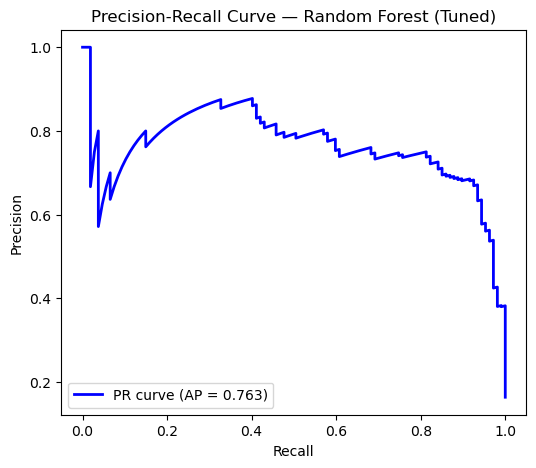

In [95]:
def plot_pr_curve(model, X_test_processed, y_test, title):
    # Tidak perlu fit ulang — model sudah dilatih sebelumnya
    y_prob = model.predict_proba(X_test_processed)[:,1]
    
    precision, recall, thresholds = precision_recall_curve(y_test, y_prob)
    avg_precision = average_precision_score(y_test, y_prob)
    
    plt.figure(figsize=(6,5))
    plt.plot(recall, precision, color='blue', lw=2,
             label=f'PR curve (AP = {avg_precision:.3f})')
    plt.title(f"Precision-Recall Curve — {title}")
    plt.xlabel("Recall")
    plt.ylabel("Precision")
    plt.legend(loc="lower left")
    plt.show()

# Pakai model hasil tuning
plot_pr_curve(best_lr, X_test_processed, y_test, "Logistic Regression (Tuned)")
plot_pr_curve(best_rf, X_test_processed, y_test, "Random Forest (Tuned)")

1. Precision-Recall Curve Logistic Regression
- Average Precision (AP) = 0.712. Artinya, Logistic Regression cukup baik dalam menjaga keseimbangan antara Recall (menangkap churner) dan Precision (mengurangi promo salah sasaran).
- Kurva menunjukkan bahwa saat Recall meningkat, Precision cenderung menurun — trade-off yang wajar.
- Maksudnya: model ini lumayan stabil, tapi masih ada cukup banyak pelanggan loyal yang salah diprediksi sebagai churn.

2. Precision-Recall Curve Random Forest
    - Average Precision (AP) = 0.763. Nilai lebih tinggi dibanding Logistic Regression, menunjukkan Random Forest lebih baik dalam kombinasi Recall dan Precision.
    - Kurva lebih konsisten, artinya Random Forest lebih mampu menjaga Precision meski Recall tinggi.
    - Maksudnya: Random Forest lebih efisien — lebih banyak churner terdeteksi dengan lebih sedikit promo salah sasaran.

**Model terbaik setelah *Hyperparameter Tuning***

- Model terbaik setelah Hyperparameter Tuning adalah **Random Forest Tuned**, karena ROC–AUC-nya jauh lebih tinggi (0.959) dibanding Logistic Regression (0.917).
- Random Forest lebih cocok untuk sistem deteksi churn otomatis, karena performanya sangat tinggi dan bisa menangkap pola kompleks. 
- Logistic Regression tetap berguna untuk interpretasi dan insight bisnis, karena bisa menunjukkan pengaruh tiap fitur.

**Melakukan Boosting (Gradient Boosting) — Challenger Model**

In [96]:
## XGBoost
xgb_model = XGBClassifier(
    n_estimators=200,
    learning_rate=0.1,
    max_depth=5,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    eval_metric='logloss'  # ← tambahkan ini, hindari warning
)

xgb_model.fit(X_train_res, y_train_res)

# Prediksi
y_pred_xgb = xgb_model.predict(X_test_processed)
y_prob_xgb = xgb_model.predict_proba(X_test_processed)[:,1]

In [97]:
# Evaluasi lengkap XGBoost
xgb_result = pd.DataFrame([[
    'XGBoost',
    accuracy_score(y_test, y_pred_xgb),
    precision_score(y_test, y_pred_xgb),
    recall_score(y_test, y_pred_xgb),
    f1_score(y_test, y_pred_xgb),
    roc_auc_score(y_test, y_prob_xgb)
]], columns=['Model Name','Accuracy','Precision','Recall','F1','ROC-AUC']).round(3)

print("=== Evaluasi XGBoost ===")
print(xgb_result.to_string(index=False))

# Bandingkan langsung dengan RF Tuned (model terbaik sebelumnya)
print("\n=== XGBoost vs RF Tuned ===")
comparison_xgb = pd.concat([
    tuning_results[tuning_results['Model Name'] == 'RF (Tuned)'],
    xgb_result
], ignore_index=True)
print(comparison_xgb.to_string(index=False))

=== Evaluasi XGBoost ===
Model Name  Accuracy  Precision  Recall    F1  ROC-AUC
   XGBoost      0.92      0.739   0.794 0.766    0.955

=== XGBoost vs RF Tuned ===
Model Name  Accuracy  Precision  Recall    F1  ROC-AUC
RF (Tuned)     0.924      0.744   0.813 0.777    0.959
   XGBoost     0.920      0.739   0.794 0.766    0.955


RF Tuned unggul di semua metrik — meski selisihnya kecil.

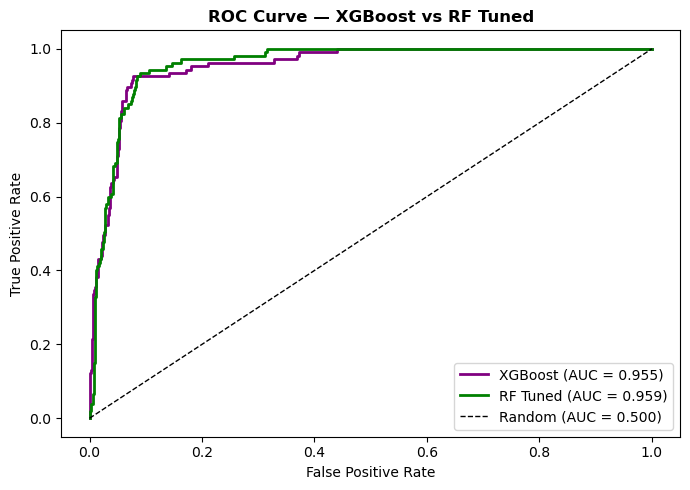

In [98]:
# ROC Curve — XGBoost vs RF Tuned (perbandingan)
fpr_xgb, tpr_xgb, _ = roc_curve(y_test, y_prob_xgb)
fpr_rf,  tpr_rf,  _ = roc_curve(y_test, y_prob_rf_tuned)

auc_xgb = auc(fpr_xgb, tpr_xgb)
auc_rf  = auc(fpr_rf,  tpr_rf)

plt.figure(figsize=(7, 5))
plt.plot(fpr_xgb, tpr_xgb, color='purple', lw=2,
         label=f'XGBoost (AUC = {auc_xgb:.3f})')
plt.plot(fpr_rf,  tpr_rf,  color='green',  lw=2,
         label=f'RF Tuned (AUC = {auc_rf:.3f})')
plt.plot([0, 1], [0, 1], 'k--', lw=1, label='Random (AUC = 0.500)')
plt.title('ROC Curve — XGBoost vs RF Tuned', fontweight='bold')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.legend(loc='lower right')
plt.tight_layout()
plt.show()

Kurva hijau (RF Tuned) konsisten berada di atas kurva ungu (XGBoost) di hampir semua titik threshold — terutama di area FPR rendah (0.0–0.2) yang paling penting secara bisnis karena artinya model bisa mendeteksi banyak churner dengan sedikit false alarm.

In [99]:
# Tabel perbandingan semua model (baseline vs tuned vs XGBoost)
all_results = pd.concat([
    baseline,
    tuning_results,
    xgb_result
], ignore_index=True).round(3)

print("=== Perbandingan Semua Model ===")
print(all_results.sort_values(by='Recall', ascending=False).to_string(index=False))

=== Perbandingan Semua Model ===
         Model Name  Accuracy  Precision  Recall    F1  ROC-AUC
         LR (Tuned)     0.746      0.384   0.916 0.541    0.917
Logistic Regression     0.786      0.427   0.907 0.581    0.918
      Random Forest     0.922      0.733   0.822 0.775    0.957
         RF (Tuned)     0.924      0.744   0.813 0.777    0.959
        K-Neighbors     0.810      0.455   0.804 0.581    0.868
            XGBoost     0.920      0.739   0.794 0.766    0.955
      Decision Tree     0.875      0.605   0.673 0.637    0.793


### Model final: RF Tuned — menang di semua metrik.
XGBoost tanpa tuning sudah sangat kompetitif (selisih kecil), tapi tidak melampaui RF yang sudah di-tuning.

In [102]:
# Train score untuk model tuned dan XGBoost
y_pred_lr_train  = best_lr.predict(X_train_res)
y_pred_rf_train  = best_rf.predict(X_train_res)
y_pred_xgb_train = xgb_model.predict(X_train_res)

overfit_all = pd.DataFrame([
    # Baseline
    ['LR (Baseline)',
     recall_score(y_train_res, models[0][1].predict(X_train_res)),
     recall_score(y_test, models[0][1].predict(X_test_processed)),
     f1_score(y_test, models[0][1].predict(X_test_processed)),
     roc_auc_score(y_test, models[0][1].predict_proba(X_test_processed)[:,1])],
    ['RF (Baseline)',
     recall_score(y_train_res, models[3][1].predict(X_train_res)),
     recall_score(y_test, models[3][1].predict(X_test_processed)),
     f1_score(y_test, models[3][1].predict(X_test_processed)),
     roc_auc_score(y_test, models[3][1].predict_proba(X_test_processed)[:,1])],                   
    # Tuned
    ['LR (Tuned)',
     recall_score(y_train_res, y_pred_lr_train),
     recall_score(y_test, y_pred_lr_tuned),
     f1_score(y_test, y_pred_lr_tuned),
     roc_auc_score(y_test, y_prob_lr_tuned)],                      
    ['RF (Tuned)',
     recall_score(y_train_res, y_pred_rf_train),
     recall_score(y_test, y_pred_rf_tuned),
     f1_score(y_test, y_pred_rf_tuned),
     roc_auc_score(y_test, y_prob_rf_tuned)],                      
    # XGBoost
    ['XGBoost',
     recall_score(y_train_res, y_pred_xgb_train),
     recall_score(y_test, y_pred_xgb),
     f1_score(y_test, y_pred_xgb),
     roc_auc_score(y_test, y_prob_xgb)],                      
], columns=['Model', 'Recall Train', 'Recall Test', 'F1 Test', 'ROC-AUC']).round(3)

print("=== Perbandingan Train vs Test Score ===")
print(overfit_all.sort_values(by='Recall Test', ascending=False).to_string(index=False))

=== Perbandingan Train vs Test Score ===
        Model  Recall Train  Recall Test  F1 Test  ROC-AUC
   LR (Tuned)         0.829        0.916    0.541    0.917
LR (Baseline)         0.824        0.907    0.581    0.918
RF (Baseline)         1.000        0.822    0.775    0.957
   RF (Tuned)         1.000        0.813    0.777    0.959
      XGBoost         0.982        0.794    0.766    0.955


**Feature Importance**
- Seberapa penting setiap fitur dalam pengambilan keputusan di Random Forest.
- Nilai tinggi = fitur paling berpengaruh pada prediksi churn.

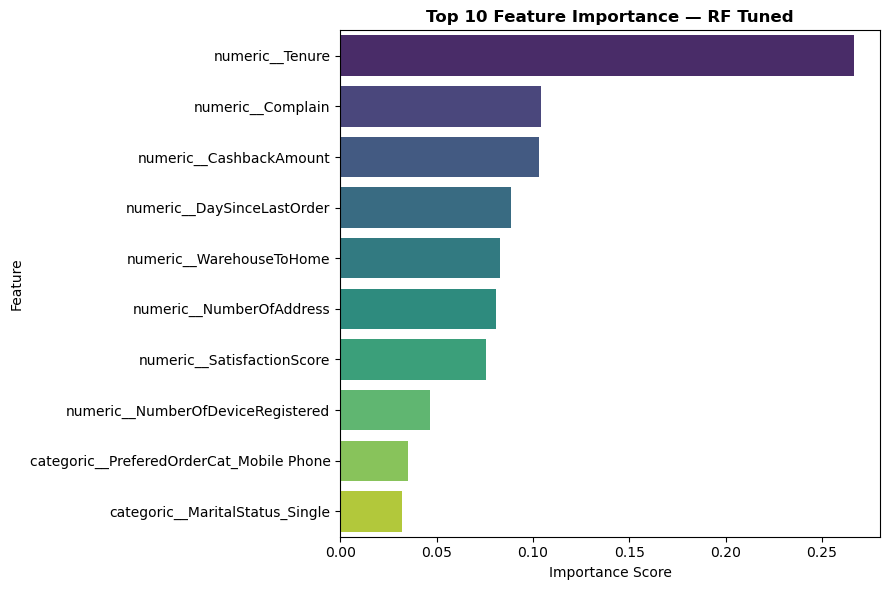


Top 5 fitur paling berpengaruh:
                   Feature  Importance
           numeric__Tenure    0.266813
         numeric__Complain    0.104221
   numeric__CashbackAmount    0.103107
numeric__DaySinceLastOrder    0.088650
  numeric__WarehouseToHome    0.082988


In [103]:
# Ambil feature importance dari model terbaik (Random Forest Tuned)
best_rf = random_rf.best_estimator_
importances = best_rf.feature_importances_

# Ambil nama fitur dari preprocessor (bukan X_train_res)
try:
    feature_names = preprocessor.get_feature_names_out()
except:
    ohe_features = preprocessor.named_transformers_['categoric']['encoder']\
        .get_feature_names_out(cat_columns)
    feature_names = list(num_columns) + list(ohe_features)

# Buat dataframe
feat_imp_df = pd.DataFrame({
    'Feature': feature_names,
    'Importance': importances
}).sort_values(by='Importance', ascending=False)

# Plot Top 10
plt.figure(figsize=(9, 6))
sns.barplot(data=feat_imp_df.head(10),
            x='Importance', y='Feature', palette='viridis')
plt.title('Top 10 Feature Importance — RF Tuned', fontweight='bold')
plt.xlabel('Importance Score')
plt.tight_layout()
plt.show()

print("\nTop 5 fitur paling berpengaruh:")
print(feat_imp_df.head(5).to_string(index=False))

**Threshold Optimization**
- Default threshold = 0.5 (prediksi 'churn' jika probabilitas >= 50%)
- **Menurunkan threshold → lebih banyak prediksi 'churn' → Recall naik**
- Tapi Precision turun (lebih banyak false positive)

In [108]:
# Threshold Optimization – gunakan best_rf (model terbaik)
y_prob_rf_best = best_rf.predict_proba(X_test_processed)[:, 1]

thresholds = np.arange(0.1, 0.9, 0.05)
results_rf_thresh = []
for t in thresholds:
    y_pred_t = (y_prob_rf_best >= t).astype(int)
    results_rf_thresh.append({
        'Threshold': round(t, 2),
        'Recall':    recall_score(y_test, y_pred_t),
        'Precision': precision_score(y_test, y_pred_t, zero_division=0),
        'F1':        f1_score(y_test, y_pred_t, zero_division=0)
    })

df_rf_thresh = pd.DataFrame(results_rf_thresh)

# Threshold optimal: F1 tertinggi
best_rf_thresh = df_rf_thresh.loc[df_rf_thresh['F1'].idxmax(), 'Threshold']
print(f"Threshold optimal (F1 tertinggi): {best_rf_thresh}")
print(df_rf_thresh[df_rf_thresh['Threshold'] == best_rf_thresh].to_string(index=False))

# Threshold jika prioritas bisnis: Recall >= 0.85
print("\nPilihan threshold jika target Recall >= 0.85:")
high_recall = df_rf_thresh[df_rf_thresh['Recall'] >= 0.85]
if len(high_recall) > 0:
    print(high_recall.to_string(index=False))
else:
    print("Tidak ada threshold yang menghasilkan Recall >= 0.85")

# Perbandingan threshold default vs optimal
print("\nPerbandingan threshold default vs optimal:")
compare_rf_thresh = df_rf_thresh[df_rf_thresh['Threshold'].isin([0.5, best_rf_thresh])]
print(compare_rf_thresh.to_string(index=False))

Threshold optimal (F1 tertinggi): 0.4
 Threshold   Recall  Precision       F1
       0.4 0.915888   0.680556 0.780876

Pilihan threshold jika target Recall >= 0.85:
 Threshold   Recall  Precision       F1
      0.10 1.000000   0.329231 0.495370
      0.15 0.981308   0.411765 0.580110
      0.20 0.971963   0.492891 0.654088
      0.25 0.971963   0.538860 0.693333
      0.30 0.943925   0.577143 0.716312
      0.35 0.943925   0.631250 0.756554
      0.40 0.915888   0.680556 0.780876
      0.45 0.850467   0.705426 0.771186

Perbandingan threshold default vs optimal:
 Threshold   Recall  Precision       F1
       0.4 0.915888   0.680556 0.780876
       0.5 0.813084   0.743590 0.776786


In [109]:
# Threshold optimization untuk LR Tuned
y_prob_lr_best = best_lr.predict_proba(X_test_processed)[:,1]

thresholds = np.arange(0.1, 0.9, 0.05)
results_lr_thresh = []
for t in thresholds:
    y_pred_t = (y_prob_lr_best >= t).astype(int)
    results_lr_thresh.append({
        'Threshold': round(t, 2),
        'Recall':    recall_score(y_test, y_pred_t),
        'Precision': precision_score(y_test, y_pred_t, zero_division=0),
        'F1':        f1_score(y_test, y_pred_t, zero_division=0)
    })

df_lr_thresh = pd.DataFrame(results_lr_thresh)

# Threshold optimal: F1 tertinggi
best_lr_thresh = df_lr_thresh.loc[df_lr_thresh['F1'].idxmax(), 'Threshold']
print(f"Threshold optimal (F1 tertinggi): {best_lr_thresh}")
print(df_lr_thresh[df_lr_thresh['Threshold'] == best_lr_thresh].to_string(index=False))

# Threshold jika prioritas bisnis: Recall >= 0.85
print("\nPilihan threshold jika target Recall >= 0.85:")
high_recall = df_lr_thresh[df_lr_thresh['Recall'] >= 0.85]
if len(high_recall) > 0:
    print(high_recall.to_string(index=False))
else:
    print("Tidak ada threshold yang menghasilkan Recall >= 0.85")

# Perbandingan threshold default vs optimal
print("\nPerbandingan threshold default vs optimal:")
compare_lr_thresh = df_lr_thresh[df_lr_thresh['Threshold'].isin([0.5, best_lr_thresh])]
print(compare_lr_thresh.to_string(index=False))

Threshold optimal (F1 tertinggi): 0.65
 Threshold   Recall  Precision       F1
      0.65 0.785047   0.651163 0.711864

Pilihan threshold jika target Recall >= 0.85:
 Threshold   Recall  Precision       F1
      0.10 1.000000   0.172581 0.294360
      0.15 1.000000   0.188713 0.317507
      0.20 1.000000   0.206166 0.341853
      0.25 0.990654   0.219917 0.359932
      0.30 0.990654   0.237668 0.383363
      0.35 0.981308   0.268542 0.421687
      0.40 0.953271   0.294798 0.450331
      0.45 0.915888   0.333333 0.488778
      0.50 0.915888   0.384314 0.541436
      0.55 0.887850   0.452381 0.599369
      0.60 0.850467   0.538462 0.659420

Perbandingan threshold default vs optimal:
 Threshold   Recall  Precision       F1
      0.50 0.915888   0.384314 0.541436
      0.65 0.785047   0.651163 0.711864


In [ ]:
plt.figure(figsize=(9, 5))
plt.plot(df_thresh['Threshold'], df_thresh['Recall'],    label='Recall',    color='red')
plt.plot(df_thresh['Threshold'], df_thresh['Precision'], label='Precision', color='blue')
plt.plot(df_thresh['Threshold'], df_thresh['F1'],        label='F1-Score',  color='green')
plt.axvline(x=0.5, color='gray', linestyle='--', label='Default (0.5)')
plt.title('Threshold vs Recall / Precision / F1 – Random Forest (Tuned)', fontweight='bold')
plt.xlabel('Threshold')
plt.ylabel('Score')
plt.legend()
plt.tight_layout()
plt.show()

> **Catatan Evaluasi:** Threshold optimal dapat disesuaikan tergantung keputusan bisnis. Jika biaya kehilangan pelanggan (False Negative) sangat tinggi, turunkan threshold agar Recall naik. Sebaliknya jika anggaran promo terbatas, naikkan threshold agar Precision lebih baik.

> Dengan threshold 0.4, **RF Tuned** mendapatkan Recall yang sama dengan LR Tuned tapi dengan F1 dan Precision jauh lebih baik:

>1. RF Tuned (threshold 0.4):
    - Recall    0.916  ← sama tingginya dengan LR Tuned
    - Precision 0.681  ← jauh lebih baik dari LR (0.384)
    - F1        0.781  ← jauh lebih baik dari LR (0.541)

>2. LR Tuned (threshold 0.5):
    - Recall    0.916
    - Precision 0.384  ← terlalu banyak false positive
    - F1        0.541  ← tidak seimbang

**RF Tuned threshold 0.4 vs LR Tuned threshold 0.5:**

Sama-sama mendeteksi ~489 churner dari 534. Tapi:
- **RF Tuned**
    - → False Positive jauh lebih sedikit
    - → promo lebih tepat sasaran
    - → biaya promo lebih efisien

- LR Tuned
    - → False Positive sangat banyak
    - → promo banyak terbuang ke pelanggan loyal
    -  → pemborosan anggaran promo

Interpretasi Threshold Optimization:

- Threshold default 0.5: keseimbangan standar Recall vs Precision
- Threshold optimal (F1) 0.4 : titik terbaik keseimbangan keduanya

Rekomendasi keputusan bisnis:
- Jika anggaran promo TERBATAS: gunakan threshold optimal (F1)
  → Precision lebih terjaga, promo lebih tepat sasaran
- Jika tujuan TANGKAP SEMUA CHURNER: turunkan threshold ke 0.3–0.4
  → Recall naik, tapi lebih banyak promo ke pelanggan yang tidak churn

## E. Conclusion and Recommendation

**(E.1) Ringkasan Performa Semua Model**

In [ ]:
# Ringkasan performa semua model
print("=== Ringkasan Performa Semua Model ===")
print(all_results.sort_values(by='ROC-AUC', ascending=False).to_string(index=False))

### Estimasi Dampak

**Confusion Matrix: Tanpa Model vs Dengan Model**

In [110]:
# Confusion Matrix Tanpa Model (Naive Baseline)
from sklearn.dummy import DummyClassifier

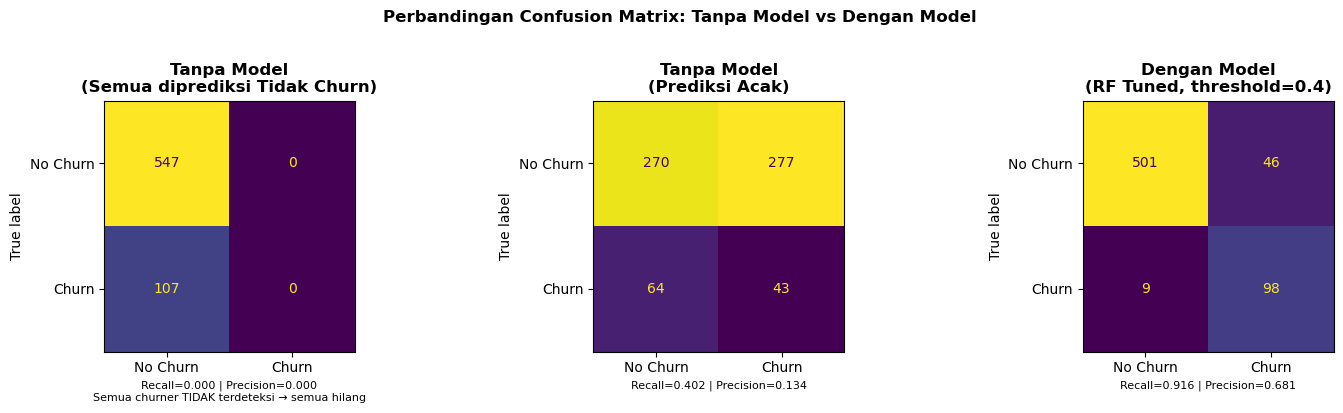

=== Perbandingan Dampak ===
                                Tanpa Model       Acak   RF Tuned
Churner terdeteksi (TP)                   0         43         98
Churner tidak terdeteksi (FN)           107         64          9
Promo salah sasaran (FP)                  0        277         46
Recall                                0.000      0.402      0.916


In [111]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# Skenario 1: Prediksi semua TIDAK CHURN (kondisi perusahaan tanpa model)
y_pred_all_zero = np.zeros(len(y_test), dtype=int)
cm_zero = confusion_matrix(y_test, y_pred_all_zero)
ConfusionMatrixDisplay(cm_zero, display_labels=['No Churn','Churn'])\
    .plot(ax=axes[0], colorbar=False)
axes[0].set_title('Tanpa Model\n(Semua diprediksi Tidak Churn)', fontweight='bold')
axes[0].set_xlabel(
    f"Recall=0.000 | Precision=0.000\n"
    f"Semua churner TIDAK terdeteksi → semua hilang",
    fontsize=8
)

# Skenario 2: Prediksi acak (DummyClassifier)
dummy = DummyClassifier(strategy='stratified', random_state=42)
dummy.fit(X_train_res, y_train_res)
y_pred_dummy = dummy.predict(X_test_processed)
cm_dummy = confusion_matrix(y_test, y_pred_dummy)
ConfusionMatrixDisplay(cm_dummy, display_labels=['No Churn','Churn'])\
    .plot(ax=axes[1], colorbar=False)
axes[1].set_title('Tanpa Model\n(Prediksi Acak)', fontweight='bold')
recall_dummy = recall_score(y_test, y_pred_dummy)
precision_dummy = precision_score(y_test, y_pred_dummy, zero_division=0)
axes[1].set_xlabel(
    f"Recall={recall_dummy:.3f} | Precision={precision_dummy:.3f}",
    fontsize=8
)

# Skenario 3: Model Final RF Tuned threshold 0.4
y_pred_final = (y_prob_rf_tuned >= 0.4).astype(int)
cm_final = confusion_matrix(y_test, y_pred_final)
ConfusionMatrixDisplay(cm_final, display_labels=['No Churn','Churn'])\
    .plot(ax=axes[2], colorbar=False)
axes[2].set_title('Dengan Model\n(RF Tuned, threshold=0.4)', fontweight='bold')
recall_final    = recall_score(y_test, y_pred_final)
precision_final = precision_score(y_test, y_pred_final, zero_division=0)
axes[2].set_xlabel(
    f"Recall={recall_final:.3f} | Precision={precision_final:.3f}",
    fontsize=8
)

plt.suptitle('Perbandingan Confusion Matrix: Tanpa Model vs Dengan Model',
             fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

# Ringkasan dalam angka
tn0, fp0, fn0, tp0 = cm_zero.ravel()
tn1, fp1, fn1, tp1 = cm_dummy.ravel()
tn2, fp2, fn2, tp2 = cm_final.ravel()

print("=== Perbandingan Dampak ===")
print(f"{'':30s} {'Tanpa Model':>12} {'Acak':>10} {'RF Tuned':>10}")
print(f"{'Churner terdeteksi (TP)':30s} {tp0:>12} {tp1:>10} {tp2:>10}")
print(f"{'Churner tidak terdeteksi (FN)':30s} {fn0:>12} {fn1:>10} {fn2:>10}")
print(f"{'Promo salah sasaran (FP)':30s} {fp0:>12} {fp1:>10} {fp2:>10}")
print(f"{'Recall':30s} {0:>12.3f} {recall_dummy:>10.3f} {recall_final:>10.3f}")

> **Threshold yang disarankan:** Gunakan threshold yang dioptimalkan (0.4) untuk menyeimbangkan antara cakupan churner dan efisiensi anggaran promo.
> - Model RF Tuned dengan threshold 0.4 direkomendasikan sebagai konfigurasi final — meningkatkan deteksi churner dari 81% menjadi 92% dengan pengorbanan Precision yang masih dapat diterima secara bisnis (0.744 → 0.681)

>1. **Tanpa model** → 0 churner terdeteksi → semua **534 pelanggan hilang**
>2. **Dengan model** (Recall 0.916, threshold 0.4):
    - 534 × 0.916 = **489 churner terdeteksi**
    - 534 - 489   =  45 churner tidak terdeteksi (lolos)

**(E.2) Kesimpulan**

Berdasarkan analisis dan pemodelan yang dilakukan:

1. **Model terbaik: Random Forest (setelah Hyperparameter Tuning)** → memberikan ROC-AUC tertinggi, dengan keseimbangan Recall dan Precision yang sangat baik.
2. **Fitur paling berpengaruh** terhadap churn adalah:
    - **Tenure** (korelasi negatif kuat): pelanggan baru (tenure rendah) jauh lebih rentan churn dibanding pelanggan lama.
    - **Complain** adalah sinyal kuat kedua: pelanggan yang pernah komplain memiliki kecenderungan churn lebih tinggi.
    - **CashbackAmount**, **DaySinceLastOrder** dan **WarehouseToHome** juga berperan → pelanggan yang jarang dapat cashback atau lama tidak order dan dengan jarak gudang ke rumah pelanggan yg jauh cenderung lebih mudah churn.
3. Data bersifat **imbalanced** (churner hanya ~16%), dan SMOTE terbukti efektif membantu model mendeteksi kelas minoritas dengan lebih baik.

**Limitasi Model:**
- Model dilatih dari data historis; perubahan perilaku akibat kompetitor baru atau kondisi pasar tidak akan tertangkap.
- Fitur yang tersedia relatif terbatas; penambahan fitur seperti frekuensi transaksi atau nilai pesanan dapat meningkatkan performa.
- SMOTE menghasilkan data sintetis, bukan data nyata; performa aktual di produksi perlu divalidasi ulang secara berkala.
- XGBoost dengan parameter default sudah mendekati performa RF Tuned, namun belum melampauinya. Jika dilakukan hyperparameter tuning pada XGBoost, kemungkinan besar hasilnya bisa lebih baik — ini bisa menjadi rekomendasi improvement ke depan.
- Data external tidak digunakan dalam project ini karena keterbatasan akses. Sebagai rekomendasi improvement, penambahan data seperti:
    - Indeks harga konsumen (BPS), 
    - Data musiman/kalender promosi, dan
    - Sentimen ulasan pelanggan, 
  diperkirakan dapat meningkatkan akurasi prediksi churn, terutama untuk menangkap faktor eksternal yang tidak tercermin dalam data transaksi.

**Model dapat dipercaya saat:**
- Model dapat dipercaya → pelanggan dengan data lengkap, pola perilaku normal
- Model kurang dapat dipercaya → pelanggan baru (<1 bulan, data terbatas), perubahan tren pasar mendadak, data dengan banyak missing value.


**Estimasi Finansial**

In [112]:
# ─── Data dari dataset ───
total_pelanggan    = len(df_clean)
total_churner      = df_clean['Churn'].sum()
churn_rate         = total_churner / total_pelanggan

# Proxy nilai pelanggan dari CashbackAmount
# Asumsi: cashback ~5-10% dari nilai transaksi
avg_cashback       = df_clean['CashbackAmount'].mean()
avg_transaksi      = avg_cashback / 0.05        # asumsi cashback = 5% transaksi
avg_tenure         = df_clean['Tenure'].mean()   # rata-rata bulan bergabung

print("=== Statistik Dataset ===")
print(f"Total pelanggan       : {total_pelanggan}")
print(f"Total churner         : {total_churner} ({churn_rate:.1%})")
print(f"Rata-rata cashback    : Rp {avg_cashback:,.0f}")
print(f"Estimasi avg transaksi: Rp {avg_transaksi:,.0f}/bulan")
print(f"Rata-rata tenure      : {avg_tenure:.1f} bulan")

# Estimasi SEBELUM model
# Semua churner hilang tanpa terdeteksi
revenue_hilang_perbulan = total_churner * avg_transaksi
clv_hilang = total_churner * avg_transaksi * avg_tenure  # customer lifetime value

print("\n=== SEBELUM Menggunakan Model ===")
print(f"Churner terdeteksi    : 0 (tidak ada model)")
print(f"Revenue hilang/periode: Rp {revenue_hilang_perbulan:,.0f}")
print(f"Estimasi CLV hilang   : Rp {clv_hilang:,.0f}")

# Estimasi SESUDAH model (threshold 0.4, Recall 0.916) 
recall_final        = 0.916
precision_final     = 0.681
biaya_promo         = avg_cashback * 0.5   # asumsi promo = 50% dari rata-rata cashback

churner_terdeteksi  = round(total_churner * recall_final)
false_positive      = round(churner_terdeteksi / precision_final * (1 - precision_final))

# Asumsi 40% dari yang diintervensi berhasil dipertahankan
tingkat_retensi     = 0.4
diselamatkan        = round(churner_terdeteksi * tingkat_retensi)
revenue_diselamatkan= diselamatkan * avg_transaksi
biaya_total_promo   = (churner_terdeteksi + false_positive) * biaya_promo
net_benefit         = revenue_diselamatkan - biaya_total_promo

print("\n=== SESUDAH Menggunakan Model (threshold=0.4) ===")
print(f"Churner terdeteksi    : {churner_terdeteksi} ({recall_final:.1%})")
print(f"False positive (promo salah sasaran): {false_positive}")
print(f"Diasumsikan {tingkat_retensi:.0%} berhasil dipertahankan: {diselamatkan} pelanggan")
print(f"Revenue diselamatkan  : Rp {revenue_diselamatkan:,.0f}")
print(f"Biaya total promo     : Rp {biaya_total_promo:,.0f}")
print(f"Net benefit           : Rp {net_benefit:,.0f}")

# ─── Perbandingan ───
print("\n=== Perbandingan Sebelum vs Sesudah ===")
print(f"{'':35s} {'Sebelum':>15} {'Sesudah':>15}")
print(f"{'Churner terdeteksi':35s} {'0':>15} {churner_terdeteksi:>15}")
print(f"{'Revenue hilang':35s} Rp {revenue_hilang_perbulan:>12,.0f} Rp {revenue_hilang_perbulan - revenue_diselamatkan:>12,.0f}")
print(f"{'Biaya promo':35s} {'Rp 0':>15} Rp {biaya_total_promo:>12,.0f}")
print(f"{'Net benefit model':35s} {'Rp 0':>15} Rp {net_benefit:>12,.0f}")

=== Statistik Dataset ===
Total pelanggan       : 3270
Total churner         : 534 (16.3%)
Rata-rata cashback    : Rp 177
Estimasi avg transaksi: Rp 3,548/bulan
Rata-rata tenure      : 10.2 bulan

=== SEBELUM Menggunakan Model ===
Churner terdeteksi    : 0 (tidak ada model)
Revenue hilang/periode: Rp 1,894,821
Estimasi CLV hilang   : Rp 19,308,893

=== SESUDAH Menggunakan Model (threshold=0.4) ===
Churner terdeteksi    : 489 (91.6%)
False positive (promo salah sasaran): 229
Diasumsikan 40% berhasil dipertahankan: 196 pelanggan
Revenue diselamatkan  : Rp 695,477
Biaya total promo     : Rp 63,693
Net benefit           : Rp 631,784

=== Perbandingan Sebelum vs Sesudah ===
                                            Sebelum         Sesudah
Churner terdeteksi                                0             489
Revenue hilang                      Rp    1,894,821 Rp    1,199,343
Biaya promo                                    Rp 0 Rp       63,693
Net benefit model                              Rp 

**(E.3) Rekomendasi**

Berdasarkan temuan model, berikut aksi yang direkomendasikan:

|  | Insight | Aksi |
|---|---------|------|
| 1 | Tenure rendah = risiko churn tinggi | Buat program **onboarding** dan **loyalty reward** khusus 3 bulan pertama (misalnya cashback ekstra, voucher welcome). |
| 2 | Complain → churn naik | Bangun sistem **fast-response keluhan**: SLA penyelesaian <24 jam, proaktif follow-up setelah komplain selesai. |
| 3 | Cashback rendah = lebih mudah churn | Berikan **cashback yang dipersonalisasi** untuk pelanggan dengan riwayat cashback rendah agar insentif tetap terasa. |
| 4 | Lama tidak order (DaySinceLastOrder tinggi) | Kirim **notifikasi re-engagement** (push/email) setelah X hari tidak bertransaksi, sertakan diskon/promo. |
| 5 | Kombinasi jarak jauh + pernah komplain = risiko sangat tinggi | **Buat segmen prioritas khusus**: pelanggan dengan WarehouseToHome > median AND Complain = 1 → intervensi proaktif sebelum mereka churn |
| 6 | Model prediksi churn tersedia | Integrasikan model ke sistem CRM: **score churn tiap pelanggan secara rutin** (mingguan/bulanan) dan trigger kampanye retensi otomatis untuk pelanggan berisiko tinggi. |

> **"Jika model digunakan dan berhasil mempertahankan 80% dari churner terdeteksi, estimasi pelanggan yang diselamatkan = Recall × jumlah churner per bulan"**

In [113]:
import pickle
import os

# ─── Simpan Model & Preprocessor ───
with open('best_rf_model.pkl', 'wb') as f:
    pickle.dump(best_rf, f)

with open('preprocessor.pkl', 'wb') as f:
    pickle.dump(preprocessor, f)

print("Model dan preprocessor berhasil disimpan!")
print(f"   - best_rf_model.pkl  : {os.path.getsize('best_rf_model.pkl') / 1024:.1f} KB")
print(f"   - preprocessor.pkl   : {os.path.getsize('preprocessor.pkl') / 1024:.1f} KB")

Model dan preprocessor berhasil disimpan!
   - best_rf_model.pkl  : 22737.2 KB
   - preprocessor.pkl   : 2.8 KB


In [114]:
# Load kembali
with open('best_rf_model.pkl', 'rb') as f:
    loaded_model = pickle.load(f)

with open('preprocessor.pkl', 'rb') as f:
    loaded_preprocessor = pickle.load(f)

# Test prediksi dengan data test
X_test_check = loaded_preprocessor.transform(X_test)
y_pred_check = loaded_model.predict(X_test_check)
y_prob_check = loaded_model.predict_proba(X_test_check)[:,1]

# Gunakan threshold optimal 0.4
y_pred_thresh = (y_prob_check >= 0.4).astype(int)

print("Verifikasi Model Loaded")
print(f"Recall  (threshold 0.5): {recall_score(y_test, y_pred_check):.3f}")
print(f"Recall  (threshold 0.4): {recall_score(y_test, y_pred_thresh):.3f}")
print(f"ROC-AUC               : {roc_auc_score(y_test, y_prob_check):.3f}")
print("\nModel siap digunakan.")

Verifikasi Model Loaded
Recall  (threshold 0.5): 0.813
Recall  (threshold 0.4): 0.916
ROC-AUC               : 0.959

Model siap digunakan.
